# EDA 3 — Typology & Validation
**Phases E + F of the EDA pipeline**

Constructs the flow regime typology from Cascade_Dominance × Cross_Decile_Share, profiles each type, and validates against IMD_Pctile_Change.

### Depends on
`msoa_cascade_features_enriched_20260616.csv` produced by `eda_1_metric_landscape_20260616.ipynb`.

---

## 12. Setup & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats 
from sklearn.metrics import cohen_kappa_score
from pathlib import Path
from pyprojroot import here

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})

ROOT = here()
DATA_DIR   = ROOT / 'outputs'
OUTPUT_DIR = ROOT / 'outputs/eda_figs'  
GEO_PATH   = ROOT / 'data/london_msoa_2011.geojson'  
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


from map_utils import load_london_msoa, plot_london_choropleth, plot_london_categorical

df = pd.read_csv(DATA_DIR / 'msoa_cascade_features_enriched_20260616.csv')
print(f'Loaded: {df.shape[0]} MSOAs, {df.shape[1]} columns')

Loaded: 983 MSOAs, 61 columns


---
## Phase E — Classifying MSOA Flow Regimes

### Typology Axes
- **Cascade_Dominance** (x-axis): which direction of deprivation-crossing flow dominates?
  - \> 0.50 → cascade-led (net downward pressure on existing residents)
  - < 0.50 → counter-led (net upward mobility signal)
  - ≈ 0.50 → symmetric (roughly balanced)
- **Cross_Decile_Share** (y-axis): how much of total migration crosses decile lines?
  - High → most migration involves socioeconomic restructuring
  - Low → most migration stays within the same deprivation tier (lateral)

---
## 13. Typology Scatter — Exploring the 2D Space

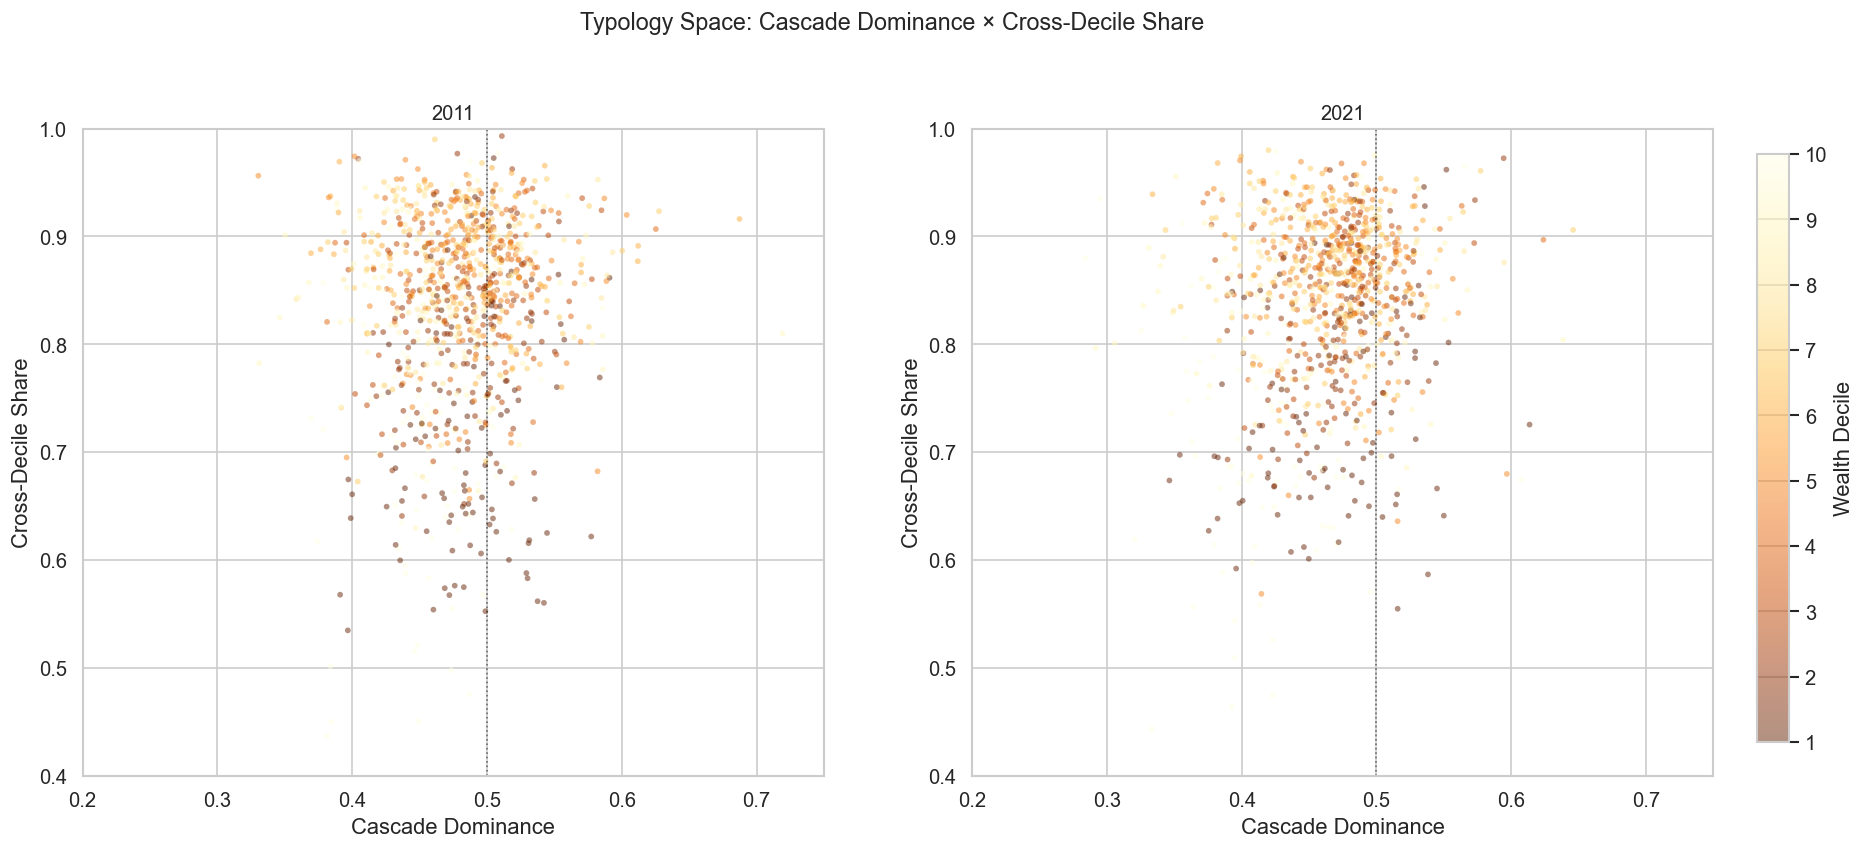


=== 2011 ===
       Cascade_Dominance_11  Cross_Decile_Share_11
count              983.0000               983.0000
mean                 0.4798                 0.8289
std                  0.0452                 0.0936
min                  0.3304                 0.4366
25%                  0.4511                 0.7825
50%                  0.4819                 0.8502
75%                  0.5066                 0.8948
max                  0.7192                 0.9932

=== 2021 ===
       Cascade_Dominance_21  Cross_Decile_Share_21
count              983.0000               983.0000
mean                 0.4638                 0.8174
std                  0.0473                 0.1459
min                  0.2841                 0.0000
25%                  0.4355                 0.7839
50%                  0.4690                 0.8527
75%                  0.4938                 0.8939
max                  0.6459                 0.9801


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    dom = f'Cascade_Dominance_{yr}'
    cds = f'Cross_Decile_Share_{yr}'
    
    scatter = ax.scatter(
        df[dom], df[cds],
        c=df['Wealth_Decile'], cmap='YlOrBr_r',
        s=12, alpha=0.5, edgecolor='none', vmin=1, vmax=10
    )
    
    ax.axvline(0.5, color='black', ls=':', lw=1, alpha=0.5, label='Dominance midline')
    ax.set_xlabel('Cascade Dominance')
    ax.set_ylabel('Cross-Decile Share')
    ax.set_title(f'20{yr}', fontsize=12)
    ax.set_xlim(0.2, 0.75)
    ax.set_ylim(0.4, 1.0)

fig.suptitle('Typology Space: Cascade Dominance × Cross-Decile Share',
             fontsize=14, y=1.02)

handles, labels = axes[0].get_legend_handles_labels()

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(scatter, cax=cbar_ax, label='Wealth Decile')

plt.savefig(OUTPUT_DIR / 'fig_12_typology_scatter_exploration.png', bbox_inches='tight')
plt.show()

for yr in ['11', '21']:
    print(f'\n=== 20{yr} ===')
    print(df[[f'Cascade_Dominance_{yr}', f'Cross_Decile_Share_{yr}']].describe().round(4).to_string())

In [3]:
# ── 1. Cloud density: what share of MSOAs fall in the visual bulk? ──
print('── 1. Cloud Density ──')
for yr in ['11', '21']:
    dom = df[f'Cascade_Dominance_{yr}']
    cds = df[f'Cross_Decile_Share_{yr}']
    in_box = ((dom >= 0.40) & (dom <= 0.55) & (cds >= 0.75) & (cds <= 0.95)).sum()
    print(f'  20{yr}: MSOAs in Dom [0.40–0.55] × CDS [0.75–0.95]: '
          f'{in_box} / {len(df)} ({in_box/len(df)*100:.1f}%)')
 
# ── 2. CDS threshold counts ──
print('\n── 2. Cross-Decile Share Threshold Counts ──')
for yr in ['11', '21']:
    cds = df[f'Cross_Decile_Share_{yr}']
    for t in [0.70, 0.75, 0.80]:
        n = (cds >= t).sum()
        print(f'  20{yr}: CDS >= {t:.2f}: {n} ({n/len(df)*100:.1f}%)')
    print()
 
# ── 3. Leftward shift ──
print('── 3. Leftward Shift (Dom > 0.5) ──')
for yr in ['11', '21']:
    dom = df[f'Cascade_Dominance_{yr}']
    above = (dom > 0.5).sum()
    print(f'  20{yr}: Dom > 0.5: {above} ({above/len(df)*100:.1f}%)')
print(f'  Mean shift:   {df["Cascade_Dominance_11"].mean():.4f} → '
      f'{df["Cascade_Dominance_21"].mean():.4f} '
      f'(Δ = {df["Cascade_Dominance_21"].mean() - df["Cascade_Dominance_11"].mean():+.4f})')
print(f'  Median shift: {df["Cascade_Dominance_11"].median():.4f} → '
      f'{df["Cascade_Dominance_21"].median():.4f} '
      f'(Δ = {df["Cascade_Dominance_21"].median() - df["Cascade_Dominance_11"].median():+.4f})')
 
# ── 4. Dominance & CDS by Wealth Decile (both years) ──
print('\n── 4. Cascade Dominance & CDS by Wealth Decile ──')
decile_summary = (df.groupby('Wealth_Decile')
    .agg(
        n=('msoa11cd', 'size'),
        Dom_11=('Cascade_Dominance_11', 'mean'),
        Dom_21=('Cascade_Dominance_21', 'mean'),
        CDS_11=('Cross_Decile_Share_11', 'mean'),
        CDS_21=('Cross_Decile_Share_21', 'mean'),
    ).round(4))
decile_summary['Dom_Δ'] = (decile_summary['Dom_21'] - decile_summary['Dom_11']).round(4)
decile_summary['CDS_Δ'] = (decile_summary['CDS_21'] - decile_summary['CDS_11']).round(4)
print(decile_summary.to_string())
 
# ── 5. Low-CDS outliers ──
print('\n── 5. Low-CDS Outliers (CDS < 0.50) ──')
for yr in ['11', '21']:
    low = df[df[f'Cross_Decile_Share_{yr}'] < 0.50]
    print(f'  20{yr}: {len(low)} MSOAs')
    if len(low) > 0:
        vc = low['Wealth_Decile'].value_counts().sort_index()
        print(f'    Decile distribution: {dict(vc)}')
 
# ── 6. Axis independence ──
print('\n── 6. Axis Independence (Spearman: Dom vs CDS) ──')
for yr in ['11', '21']:
    rho, p = stats.spearmanr(
        df[f'Cascade_Dominance_{yr}'], df[f'Cross_Decile_Share_{yr}'])
    print(f'  20{yr}: ρ = {rho:.3f}, p = {p:.2e}')

── 1. Cloud Density ──
  2011: MSOAs in Dom [0.40–0.55] × CDS [0.75–0.95]: 702 / 983 (71.4%)
  2021: MSOAs in Dom [0.40–0.55] × CDS [0.75–0.95]: 694 / 983 (70.6%)

── 2. Cross-Decile Share Threshold Counts ──
  2011: CDS >= 0.70: 880 (89.5%)
  2011: CDS >= 0.75: 809 (82.3%)
  2011: CDS >= 0.80: 700 (71.2%)

  2021: CDS >= 0.70: 871 (88.6%)
  2021: CDS >= 0.75: 806 (82.0%)
  2021: CDS >= 0.80: 694 (70.6%)

── 3. Leftward Shift (Dom > 0.5) ──
  2011: Dom > 0.5: 319 (32.5%)
  2021: Dom > 0.5: 184 (18.7%)
  Mean shift:   0.4798 → 0.4638 (Δ = -0.0160)
  Median shift: 0.4819 → 0.4690 (Δ = -0.0129)

── 4. Cascade Dominance & CDS by Wealth Decile ──
                n  Dom_11  Dom_21  CDS_11  CDS_21   Dom_Δ   CDS_Δ
Wealth_Decile                                                    
1              99  0.4869  0.4687  0.7146  0.7131 -0.0182 -0.0015
2              98  0.4822  0.4722  0.8112  0.8017 -0.0100 -0.0095
3              98  0.4791  0.4692  0.8488  0.8230 -0.0099 -0.0258
4              98  0

### Fig 12 Interpretation

This plot pairs Dominance with Cross-Decile Share (proportion of all migration that crosses a decile boundary in either direction).

From this plot, we can test if an individual MSOA's migration is fundamentally about socioeconomic restructuring, or is most of it within-tier. -- **share of migration that involves any cross-decile movement.**
- An MSOA can have high cross-decile share but with 0.5 dominance. This means lots of deprivation-crossing movement but perfectly balanced between up and down.

- **The dominant pattern is a dense, continuous cloud, not discrete clusters.**
    - The bulk of MSOAs sit beterrn roughly 0.4-0.55 on dominance and 0.75-0.95 on cross-decile share.
    - **Most London neighbourhoods have high rates of socioeconomic restructuring through migration** (in 88.6% MSOAs in 2021, at least 70% of migration flows cross a deprivation decile boundary)
        - **Socioeconomic restructuring through migration is the norm rather than the exception.**
    - For most of above neighbourhoods, **the directional balance between cascade and counter-cascade is farily close to even, though tilted slightly counter-cascade-ward**, since the cloud centre sits left of the 0.5 midline.
- **The leftward shift from 2011 and 2021.** (similar results in fig 10)
    - MSOAs with cascade dominance >0.5 dropped (32.5% in 2011 to 18.7% in 2021)
    - The mean dominance droppedn (0.48 in 2011 to 0.464 in 2021)
    - **Across London, counter-cascade flows became relatively more prevalent.**
- There is a deprivation-position effect in both 2011 and 2021.
    - In 2021, **Wealthiest MSOAs** (D10) sit further left with a mean dominance of 0.425 -- **disproportionately export residents to more deprived areas**, rather than receiving from them.
    - Most deprived MSOAs sit closer to the midline at 0.469 in 2021.
    - In 2011, the gap between Decile 1 (0.487) and Decile 10 (0.455) is only about 0.03, whereas in 2021, this widens slightly to 0.04 (0.469 vs. 0.425) 
    - The wealthiest areas have limited "upward" room in the hierarchy, so the cross-decile flows are naturally counter-dominated.
- **The y-axis reveals a U-shaped by deprivation in both 2011 and 2021.**
    - Both the most deprived and most affluent MSOAs have the lowest cross-decile shares (clearer pattern in 2021), while mid-tier neighbourhoods (D4-D8) cluster around 0.84-0.87.
    - This aligns with the right above finding, where areas at the extremes of the hierarchy have fewer "available" decile boundaries to cross, so a larger share of its flows are lateral within the bottom tiers.
- **Low Cross-Decile (<0.5) increased in 2021 from 2011.**
    - In 2011, all MSOAs with CDS below 0.5 were in Decile 10.
        - These are the wealthiest areas where lateral migration is a celling effect.
    - By 2021, 23 MSOAs with CDS below 0.5, scattered across Decile 1-7 and 10.
        - **Emergence of low-CDS areas across the deprivation spectrum in 2021.**
- **Two axes are uncorrelated (rho=0.08).**
    - Two metrics capture genuienly independent dimensions of the flow regime,
    - This supports using both axes jointly for the typology rather than replying on either alone.

---
## 14. Typology Construction

Based on the scatter exploration, we define thresholds. 

The initial approach uses the natural midline (0.50) for Cascade_Dominance and a percentile-based threshold for Cross_Decile_Share.

In [4]:
def assign_typology(row, yr='21',
                    dom_upper=0.52, dom_lower=0.48,
                    cds_threshold=None):
    """
    Classify MSOA into flow regime typology.
    
    Parameters
    ----------
    dom_upper, dom_lower : float
        Cascade_Dominance thresholds. 
        > dom_upper → cascade-led; < dom_lower → counter-led; between → symmetric
    cds_threshold : float
        Cross_Decile_Share below this → lateral-dominated.
        Default: 25th percentile of CDS distribution.
    """
    dom = row[f'Cascade_Dominance_{yr}']
    cds = row[f'Cross_Decile_Share_{yr}']
    
    if cds < cds_threshold:
        return 'Lateral'
    elif dom > dom_upper:
        return 'Cascade-led'
    elif dom < dom_lower:
        return 'Counter-led'
    else:
        return 'Symmetric'

# Compute threshold (25th percentile of Cross_Decile_Share)
cds_p25 = df['Cross_Decile_Share_21'].quantile(0.25)
print(f'Cross_Decile_Share 25th percentile (2021): {cds_p25:.4f}')

# Apply typology
df['Typology_21'] = df.apply(
    assign_typology, axis=1, yr='21', cds_threshold=cds_p25
)

# Also for 2011
cds_p25_11 = df['Cross_Decile_Share_11'].quantile(0.25)
df['Typology_11'] = df.apply(
    assign_typology, axis=1, yr='11', cds_threshold=cds_p25_11
)


print(f'\n=== Typology Distribution (2011) ===')
print(df['Typology_11'].value_counts().to_string())
print(f'\n=== Typology Distribution (2021) ===')
print(df['Typology_21'].value_counts().to_string())

Cross_Decile_Share 25th percentile (2021): 0.7839

=== Typology Distribution (2011) ===
Typology_11
Counter-led    340
Symmetric      267
Lateral        246
Cascade-led    130

=== Typology Distribution (2021) ===
Typology_21
Counter-led    423
Lateral        246
Symmetric      242
Cascade-led     72


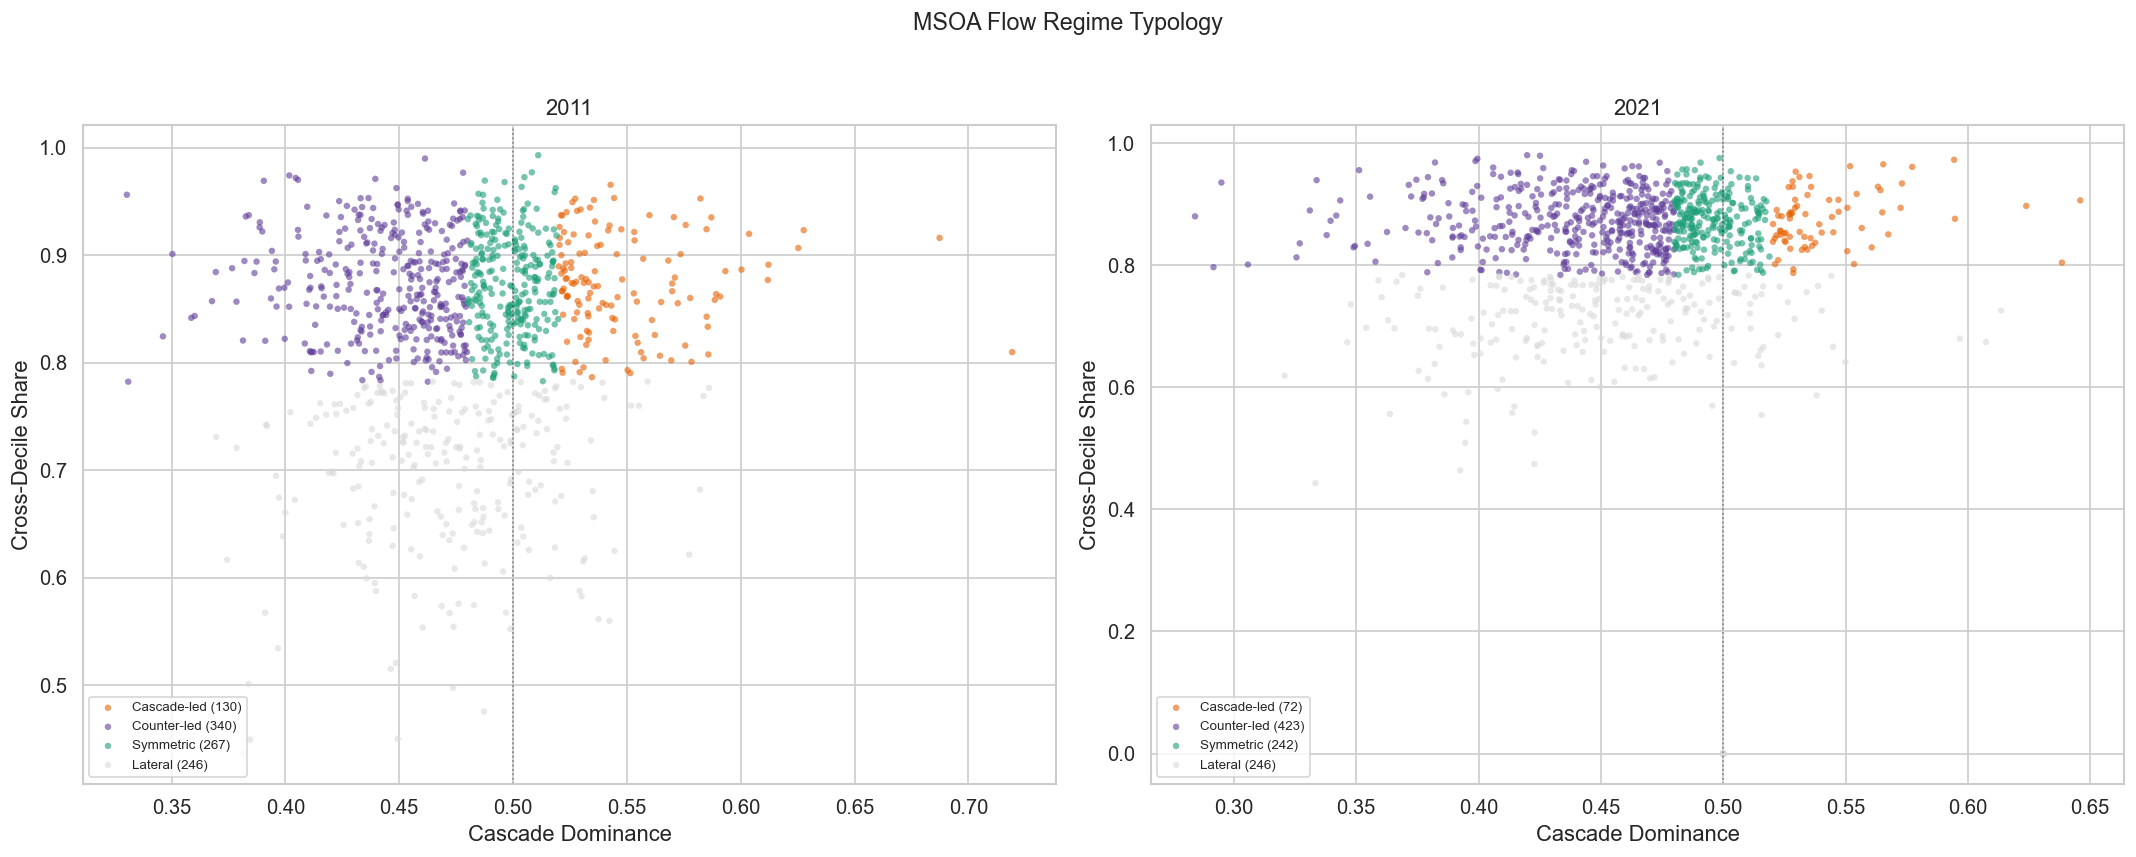

In [50]:
# ── Typology scatter — coloured by type ───────────────────────
TYPOLOGY_COLORS = {
    'Cascade-led':  '#e66101',   # burnt orange
    'Counter-led':  '#5e3c99',   # deep violet
    'Symmetric':    '#1b9e77',   # teal-green
    'Lateral':      '#d9d9d9',   # light grey
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    dom = f'Cascade_Dominance_{yr}'
    cds = f'Cross_Decile_Share_{yr}'
    typ = f'Typology_{yr}'
    
    for tname, tcolor in TYPOLOGY_COLORS.items():
        mask = df[typ] == tname
        ax.scatter(df.loc[mask, dom], df.loc[mask, cds],
                   c=tcolor, s=15, alpha=0.6, edgecolor='none',
                   label=f'{tname} ({mask.sum()})')
    
    ax.axvline(0.5, color='black', ls=':', lw=1, alpha=0.4)
    ax.set_xlabel('Cascade Dominance')
    ax.set_ylabel('Cross-Decile Share')
    ax.set_title(f'20{yr}')
    ax.legend(fontsize=8, loc='lower left')

fig.suptitle('MSOA Flow Regime Typology', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_13_typology_scatter_classified.png')
plt.show()

### Fig 13 Interpretation

**Explanation of axises and typology thresholds:**
x-axis captures the directional balance of cross-decile flows; 
- above 0.5: cascade dominated --- threshold to be 0.52
- below 0.5: counter-cascade dominated
y-axis captures how much of total migration crosses deprivation tiers
- High: most movement involved socioeconomic resturcturing --- threshold to be 25th percentile
- Low: most movers stay within the same deprivation tier


**There is massice shift toward counter-cascade dominance between 2011 and 2021. (Every decile-mean sits below 0.5 in both periods, and the gap widened by 2021, consistent with eda_2)**
- Visually, the entire cloud drifts leftward.
- Cascade-led MSOAs nearly halve, 130 to 72.
- Counter-led MSOAs grow substantially, 340 to 423.

**Cross-Decile Share distribution is more dispersed by 2021. Alarger share of MSOAs had their migration become predominantly within the same deprivation band by 2021. This would partly attribute to COVID-era migration patterns, where longer-distance cross-tier moved may haven been suppressed.**
- In 2021, there are points dropping well below 0.4, even approaching 0.
- In 2011, virtually every points sit above 0.5.

**Symmetric category (CDS in 25th percentile, cascade_dominance between 0.52 and 0.48) stays relatively stable.**
- ~267 to 242.
- Stable: Narrow band around the midline.
- Slight decrease: Because of the gernal leftward drift, some formerly symmetric MSOAs topped into counter-led territory rather than being replaced.

---

This plot complicates the narrative that treats cascading displacement as the dominant migration dynamic in London.

**Cascade flows are not a city-wide phenomenon. They operate most intensely in specific deprived-to-middle-band MSOAs.**

**Counter-cascade pattern is actually more common. This is essentially the opposite direction to the gentrification-displacement story.**

> Cascade_Dominance now is the ratio, what about the difference between `CFI_Churn` and `Counter_Churn`?

---
## 14b. Sensitivity Test — Cascade Dominance: Ratio vs Difference

The current `Cascade_Dominance` is a **ratio**: `CFI_Churn / (CFI_Churn + Counter_Churn)`, bounded [0, 1] with 0.50 as the natural midline.

An alternative is the **difference**: `CFI_Churn − Counter_Churn`, unbounded and centred on zero.

This section tests whether the two formulations produce materially different typology assignments, and if so, which MSOAs are affected.

In [51]:
# ── 14b-1  Compute difference-based dominance ─────────────────
for yr in ['11', '21']:
    cfi  = df[f'CFI_Churn_{yr}']
    cc   = df[f'Counter_Churn_{yr}']
    df[f'Cascade_Diff_{yr}'] = cfi - cc

print('=== Descriptive Statistics ===')
for yr in ['11', '21']:
    print(f'\n── 20{yr} ──')
    ratio = df[f'Cascade_Dominance_{yr}']
    diff  = df[f'Cascade_Diff_{yr}']
    print(f'  Ratio  — mean: {ratio.mean():.4f}, median: {ratio.median():.4f}, '
          f'std: {ratio.std():.4f}, range: [{ratio.min():.4f}, {ratio.max():.4f}]')
    print(f'  Diff   — mean: {diff.mean():.1f}, median: {diff.median():.1f}, '
          f'std: {diff.std():.1f}, range: [{diff.min():.0f}, {diff.max():.0f}]')
    # Percentage on each side of midline
    ratio_casc = (ratio > 0.5).mean() * 100
    diff_casc  = (diff > 0).mean() * 100
    print(f'  % cascade-dominated: ratio={ratio_casc:.1f}%, diff={diff_casc:.1f}%')

=== Descriptive Statistics ===

── 2011 ──
  Ratio  — mean: 0.4798, median: 0.4819, std: 0.0452, range: [0.3304, 0.7192]
  Diff   — mean: -36.2, median: -42.0, std: 125.7, range: [-464, 1015]
  % cascade-dominated: ratio=32.5%, diff=32.5%

── 2021 ──
  Ratio  — mean: 0.4638, median: 0.4690, std: 0.0473, range: [0.2841, 0.6459]
  Diff   — mean: -71.9, median: -69.0, std: 101.1, range: [-634, 628]
  % cascade-dominated: ratio=18.7%, diff=18.7%


In [52]:
# ── 14b-2  Correlation between ratio and difference ───────────
print('=== Correlation: Ratio vs Difference ===')
for yr in ['11', '21']:
    r_pearson, p_p = stats.pearsonr(df[f'Cascade_Dominance_{yr}'], df[f'Cascade_Diff_{yr}'])
    r_spearman, p_s = stats.spearmanr(df[f'Cascade_Dominance_{yr}'], df[f'Cascade_Diff_{yr}'])
    print(f'  20{yr}: Pearson r = {r_pearson:.4f} (p={p_p:.1e}), '
          f'Spearman ρ = {r_spearman:.4f} (p={p_s:.1e})')

=== Correlation: Ratio vs Difference ===
  2011: Pearson r = 0.8972 (p=0.0e+00), Spearman ρ = 0.9515 (p=0.0e+00)
  2021: Pearson r = 0.8418 (p=5.5e-265), Spearman ρ = 0.9220 (p=0.0e+00)


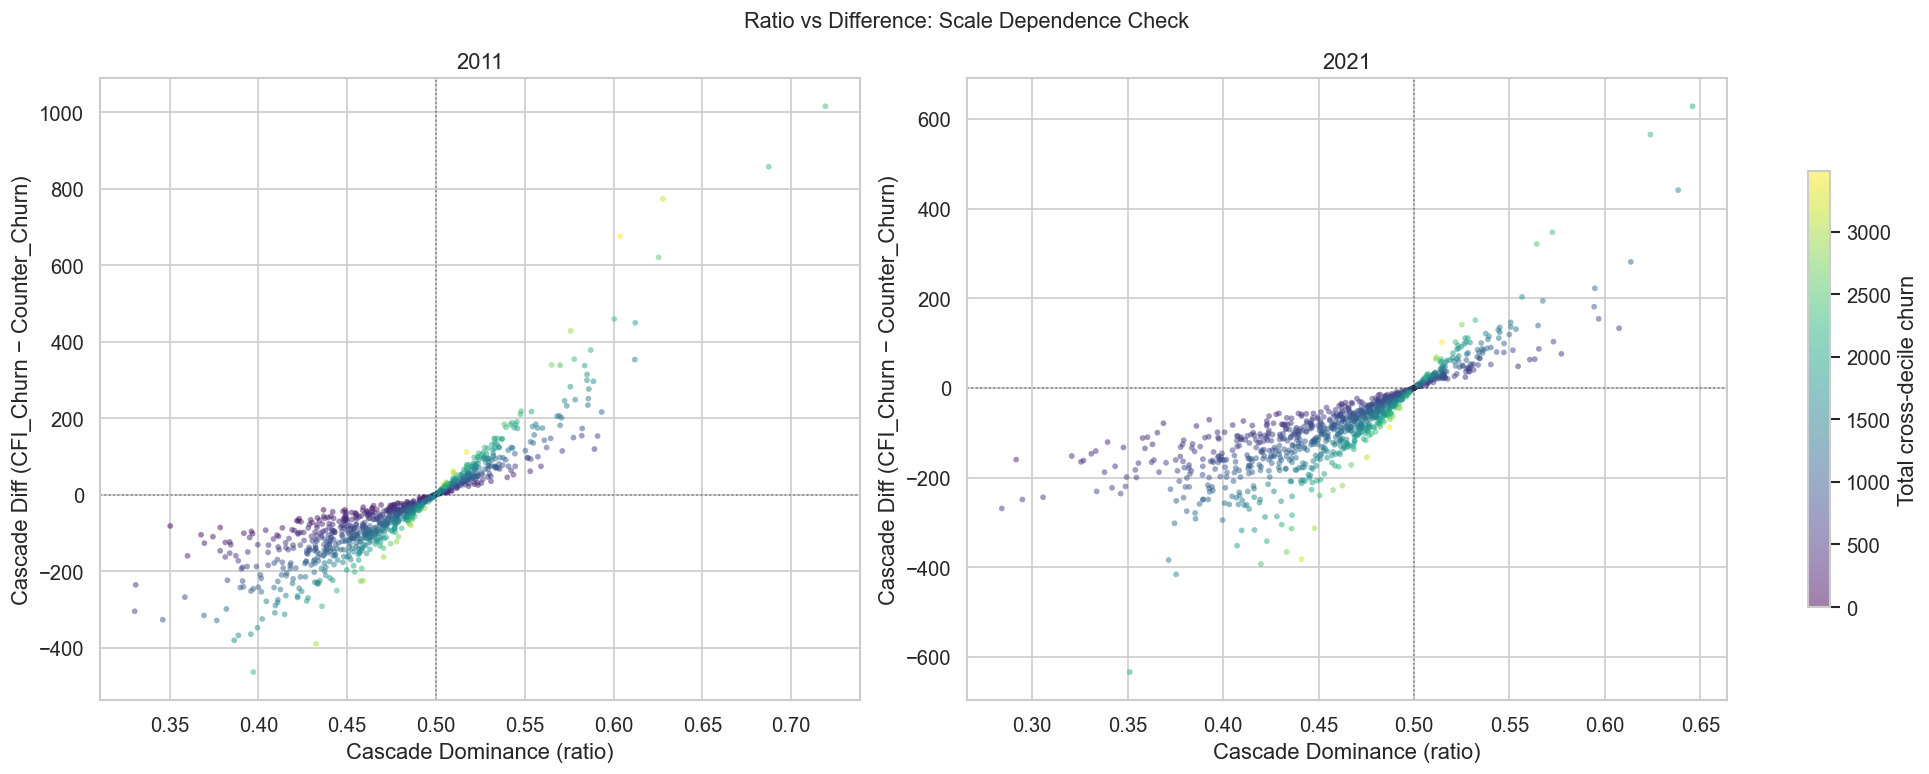

In [53]:
# ── 14b-3  Scatter: ratio vs difference, coloured by churn ────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    total_churn = df[f'CFI_Churn_{yr}'] + df[f'Counter_Churn_{yr}']
    sc = ax.scatter(
        df[f'Cascade_Dominance_{yr}'], df[f'Cascade_Diff_{yr}'],
        c=total_churn, cmap='viridis', s=12, alpha=0.5, edgecolor='none'
    )
    ax.axvline(0.5, color='black', ls=':', lw=1, alpha=0.4)
    ax.axhline(0,   color='black', ls=':', lw=1, alpha=0.4)
    ax.set_xlabel('Cascade Dominance (ratio)')
    ax.set_ylabel('Cascade Diff (CFI_Churn − Counter_Churn)')
    ax.set_title(f'20{yr}')

plt.colorbar(sc, ax=axes, label='Total cross-decile churn', shrink=0.7, pad=0.05)
fig.suptitle('Ratio vs Difference: Scale Dependence Check', fontsize=13, y=1.05)

plt.savefig(OUTPUT_DIR / 'fig_13b_ratio_vs_diff_scatter.png', dpi=150)
plt.show()

### Fig 13b Interpretation:

Ratios and Differences show the same pattern.

- The fan shape shows MSOAs near ratio 0.5 span a wide range of differences, but MSOAs at the ratio extremes converge toward a tighter relationship.
- Outliers in the fan are the highest-churn MSOAs.

In 2021,
- The range of the cloud is more overall compressed 
    - This reflects again the decline in migration volumes between census due to COVID.
- Its centre moved slightly more negative.
    - This is the same as leftward-shift in Ratio-based.

Compare 2021 from 2011, the cloud looks like an upward shift.
    - Extreme positive outliers in 2011 are compressed in 2021, making the bulk of the cloud appear relatively higher.
    - This is an ceiling effect from lower total cvolumes, not an acutal upward shift in the distribution's centre.

In [54]:
# ── 14b-4  Side disagreement: opposite sides of midline ───────
# An MSOA "disagrees" if ratio says cascade-led but diff says counter-led,
# or vice versa.
print('=== Side Disagreement (ratio vs diff on opposite sides of midline) ===')
for yr in ['11', '21']:
    ratio_side = np.sign(df[f'Cascade_Dominance_{yr}'] - 0.5)  # +1 cascade, -1 counter
    diff_side  = np.sign(df[f'Cascade_Diff_{yr}'])              # +1 cascade, -1 counter

    # Exclude exact-midline cases (sign = 0)
    valid = (ratio_side != 0) & (diff_side != 0)
    disagree = (ratio_side[valid] != diff_side[valid]).sum()
    n_valid = valid.sum()

    print(f'\n  20{yr}: {disagree}/{n_valid} MSOAs disagree '
          f'({disagree / n_valid * 100:.1f}%)')

    if disagree > 0:
        mask = valid & (ratio_side != diff_side)
        disag_df = df.loc[mask, ['msoa11cd', 'ladnm', 'Wealth_Decile',
                                  f'Cascade_Dominance_{yr}', f'Cascade_Diff_{yr}',
                                  f'CFI_Churn_{yr}', f'Counter_Churn_{yr}']].copy()
        disag_df['Total_Cross_Churn'] = (disag_df[f'CFI_Churn_{yr}']
                                         + disag_df[f'Counter_Churn_{yr}'])
        print(f'    Disagreeing MSOAs:')
        print(disag_df.to_string(index=False))
    else:
        print('    No disagreements — ratio and difference agree on '
              'every MSOA\'s cascade/counter side.')

=== Side Disagreement (ratio vs diff on opposite sides of midline) ===

  2011: 0/983 MSOAs disagree (0.0%)
    No disagreements — ratio and difference agree on every MSOA's cascade/counter side.

  2021: 0/962 MSOAs disagree (0.0%)
    No disagreements — ratio and difference agree on every MSOA's cascade/counter side.


In [55]:
# ── 14b-5  Typology comparison using difference-based thresholds ──
# To make the comparison fair, use symmetric thresholds around 0
# that capture the same *share* of MSOAs as the ratio thresholds.

for yr in ['11', '21']:
    # Count how many MSOAs fall in the ratio's symmetric band [0.48, 0.52]
    ratio_sym_share = ((df[f'Cascade_Dominance_{yr}'] >= 0.48) &
                       (df[f'Cascade_Dominance_{yr}'] <= 0.52)).mean()

    # Find equivalent bandwidth around 0 for the difference
    diff_abs = df[f'Cascade_Diff_{yr}'].abs()
    diff_threshold = diff_abs.quantile(ratio_sym_share)

    print(f'20{yr}: ratio symmetric band captures {ratio_sym_share*100:.1f}% of MSOAs')
    print(f'       equivalent diff threshold: ±{diff_threshold:.0f}')

    # Assign diff-based typology
    cds_col = f'Cross_Decile_Share_{yr}'
    cds_p25 = df[cds_col].quantile(0.25)

    def assign_diff_typology(row):
        d = row[f'Cascade_Diff_{yr}']
        cds = row[cds_col]
        if cds < cds_p25:
            return 'Lateral'
        elif d > diff_threshold:
            return 'Cascade-led'
        elif d < -diff_threshold:
            return 'Counter-led'
        else:
            return 'Symmetric'

    df[f'Typology_Diff_{yr}'] = df.apply(assign_diff_typology, axis=1)

# Cross-tabulation: ratio typology vs diff typology
print('\n=== Cross-Tabulation: Ratio vs Difference Typology (2021) ===')
ct = pd.crosstab(df['Typology_21'], df['Typology_Diff_21'],
                 margins=True, margins_name='Total')
print(ct.to_string())

# Agreement rate
agree = (df['Typology_21'] == df['Typology_Diff_21']).mean()
print(f'\nOverall agreement: {agree*100:.1f}%')

# Cohen's kappa
kappa = cohen_kappa_score(df['Typology_21'], df['Typology_Diff_21'])
print(f'Cohen\'s κ: {kappa:.3f}')

2011: ratio symmetric band captures 35.1% of MSOAs
       equivalent diff threshold: ±46
2021: ratio symmetric band captures 31.0% of MSOAs
       equivalent diff threshold: ±50

=== Cross-Tabulation: Ratio vs Difference Typology (2021) ===
Typology_Diff_21  Cascade-led  Counter-led  Lateral  Symmetric  Total
Typology_21                                                          
Cascade-led                57            0        0         15     72
Counter-led                 0          402        0         21    423
Lateral                     0            0      246          0    246
Symmetric                   8           34        0        200    242
Total                      65          436      246        236    983

Overall agreement: 92.1%
Cohen's κ: 0.884


- 15 MSOAs Ratio `Cascade-led` are Difference `Symmetric`.
- 21 MSOAs Ratio `Counter-led` are Difference `Symmetric`.
- 8 MSOAs Ratio `Symmetric` are Difference `Cascade-led`.
- 34 MSOA Ratio `Symmetric` are Difference `Counter-led`.

Since we know the overall counter-led prevalence, the gap between 34 and 8 makes sense. Specifically, if an MSOA sits at ratio 0.49, which is inside the `Symmetric` ratio band, it will have a negative difference. And if this difference is large enough to across the +-50 threshold, it will go into the `Counter-led` classification. Therefore, given the counter-cascade side is more populated near the boundary, more MSOAs are pushed in this way.

> Would the difference-based metric give clearer conclusion of counter-led phenomenon in London?

In [56]:
# ── 14b-6  Where do the two formulations disagree? ────────────
# Focus on MSOAs that switch between Cascade-led and Counter-led
# (the substantively important disagreement)
yr = '21'
switched = df[
    ((df['Typology_21'] == 'Cascade-led') & (df[f'Typology_Diff_{yr}'] == 'Counter-led')) |
    ((df['Typology_21'] == 'Counter-led') & (df[f'Typology_Diff_{yr}'] == 'Cascade-led'))
]

print(f'MSOAs that flip between Cascade-led ↔ Counter-led: {len(switched)}')
if len(switched) > 0:
    print(switched[['msoa11cd', 'ladnm', 'Wealth_Decile',
                     'Cascade_Dominance_21', 'Cascade_Diff_21',
                     'CFI_Churn_21', 'Counter_Churn_21',
                     'Typology_21', f'Typology_Diff_{yr}']].to_string(index=False))
else:
    print('No substantive flips — ratio and difference never place an MSOA '
          'on opposite sides of the cascade/counter boundary.')

MSOAs that flip between Cascade-led ↔ Counter-led: 0
No substantive flips — ratio and difference never place an MSOA on opposite sides of the cascade/counter boundary.


In [57]:
# ── 14b-7  Scale dependence diagnostic ────────────────────────
# The key difference: does total churn predict the disagreements?
# If the diff version is scale-dependent, disagreements should
# concentrate in high-churn MSOAs.

yr = '21'
df['_total_xdec_churn'] = df[f'CFI_Churn_{yr}'] + df[f'Counter_Churn_{yr}']
df['_typology_agrees'] = (df['Typology_21'] == df[f'Typology_Diff_{yr}'])

disagree_mask = ~df['_typology_agrees']
if disagree_mask.sum() > 0:
    print('=== Scale Dependence: Churn of Agreeing vs Disagreeing MSOAs ===')
    print(f'  Agree   (n={df["_typology_agrees"].sum():>3d}): '
          f'mean churn = {df.loc[df["_typology_agrees"], "_total_xdec_churn"].mean():.0f}')
    print(f'  Disagree (n={disagree_mask.sum():>3d}): '
          f'mean churn = {df.loc[disagree_mask, "_total_xdec_churn"].mean():.0f}')

    # Mann-Whitney test
    u_stat, u_p = stats.mannwhitneyu(
        df.loc[df['_typology_agrees'], '_total_xdec_churn'],
        df.loc[disagree_mask, '_total_xdec_churn'],
        alternative='two-sided'
    )
    print(f'  Mann-Whitney U = {u_stat:.0f}, p = {u_p:.3e}')

    # Decile distribution of disagreements
    print(f'\n  Decile distribution of disagreements:')
    print(f'  {df.loc[disagree_mask, "Wealth_Decile"].value_counts().sort_index().to_dict()}')
else:
    print('No disagreements to analyse for scale dependence.')

# Clean up temp columns
df.drop(columns=['_total_xdec_churn', '_typology_agrees'], inplace=True)

=== Scale Dependence: Churn of Agreeing vs Disagreeing MSOAs ===
  Agree   (n=905): mean churn = 1154
  Disagree (n= 78): mean churn = 1495
  Mann-Whitney U = 28152, p = 2.990e-03

  Decile distribution of disagreements:
  {1: 9, 2: 6, 3: 13, 4: 8, 5: 7, 6: 13, 7: 4, 8: 9, 9: 6, 10: 3}


The Mann-Whitney U test is test if randomly picking one MSOA from the "agree" group and one from the "disagree" group, is the churn of one systematically higher than the other. In short, ranking all values together and checking whether one group's ranks are systematically shifted.

The result shows disagreeing MSOAs have statistically significantly higher total cross-decile churn than agreeing MSOAs.

**The difference-based typology is scale-dependent.**
- From the result, high0churn MSOAs get reclassified.
- The ratio-based typology normalises these volume differences, by treating MSOA with the same directional balance. e.g. a 60/40 split reas the same whether total churn is 100 or 2000.

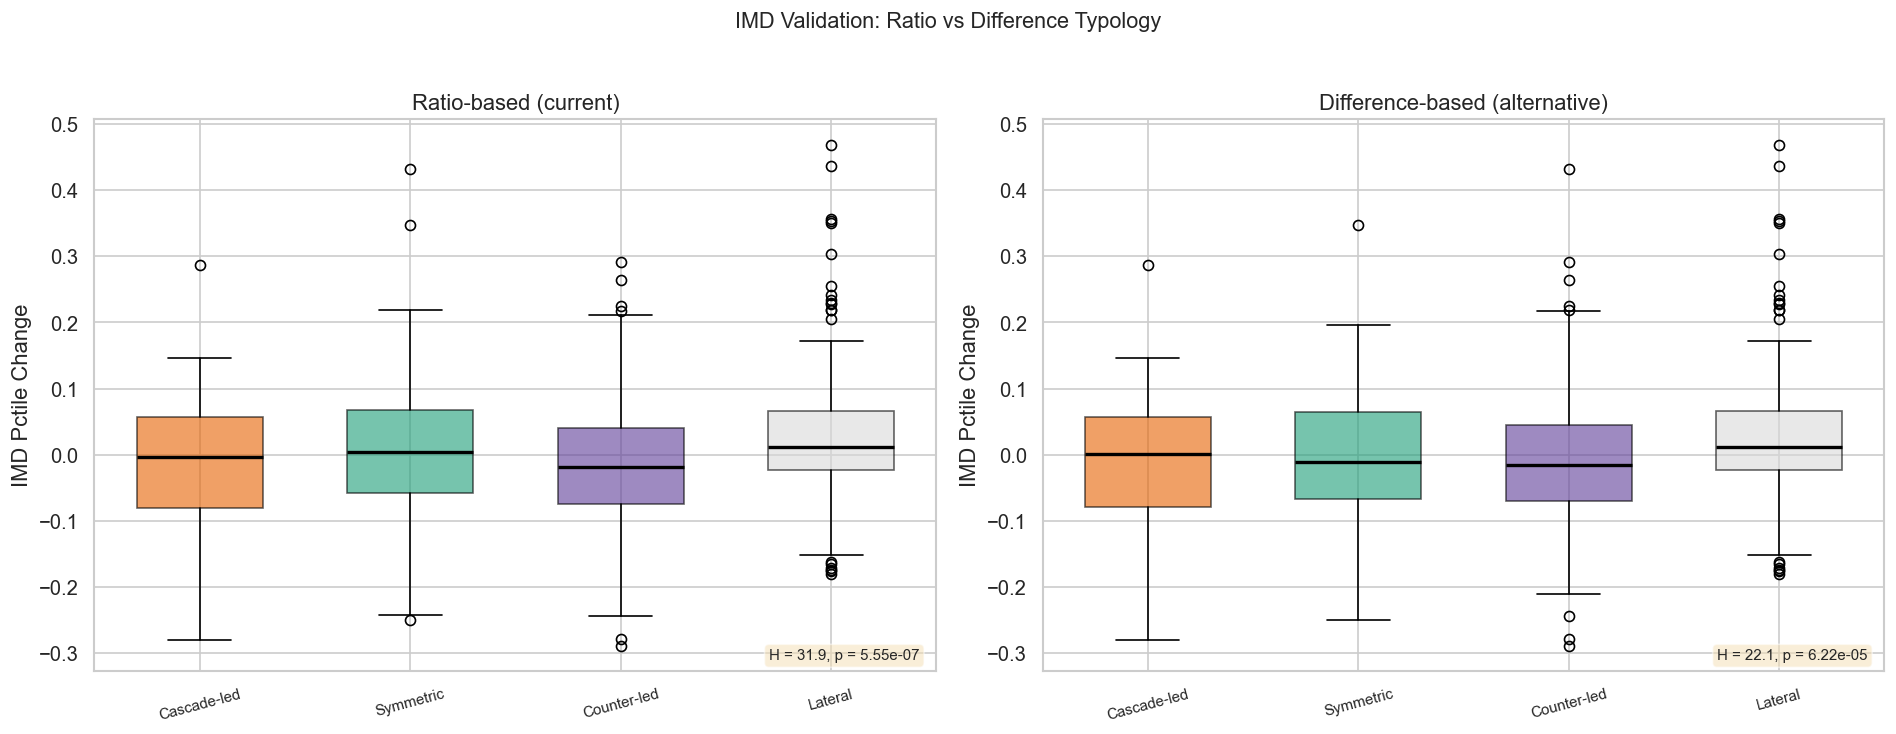

In [58]:
# ── 14b-8  IMD validation comparison ──────────────────────────
# Does the difference-based typology predict IMD_Pctile_Change
# better, worse, or the same as the ratio-based one?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order = ['Cascade-led', 'Symmetric', 'Counter-led', 'Lateral']

for idx, (typ_col, title) in enumerate([
    ('Typology_21', 'Ratio-based (current)'),
    ('Typology_Diff_21', 'Difference-based (alternative)')
]):
    ax = axes[idx]
    data = [df.loc[df[typ_col] == t, 'IMD_Pctile_Change'].dropna().values
            for t in order]
    bp = ax.boxplot(data, positions=range(len(order)), patch_artist=True, widths=0.6)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(TYPOLOGY_COLORS[order[i]])
        box.set_alpha(0.6)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(2)

    ax.set_xticklabels(order, fontsize=9, rotation=15)
    ax.set_ylabel('IMD Pctile Change')
    ax.set_title(title)

    # Kruskal-Wallis
    kw_stat, kw_p = stats.kruskal(*[g for g in data if len(g) > 0])
    ax.annotate(f'H = {kw_stat:.1f}, p = {kw_p:.2e}',
                xy=(0.98, 0.02), xycoords='axes fraction', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('IMD Validation: Ratio vs Difference Typology', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_13c_ratio_vs_diff_imd_validation.png', dpi=150)
plt.show()

### Ratio vs Difference on cascade dominance metric design

- **The ratio and difference can never disagree on direction.** This is mathematically gurantreed, so no directional flips as expected

- **There is 7.9% disagreement about the bandwidth.** 
    - Every disagreement is a `Symmetric` and `Counter-led` swap.
    - 34 MSOAs changed from `Symmetric` by Ratio to `Counter-led` by Difference.
    - 8 MSOAs changed from `Counter-led` by Ratio to `Symmetric` by Difference.
- **The asymmetric swap can be some MSOAs sit inside the ratio +-0.2 band beyond the +-50 difference.**
    - Most MSOAs lean counter-cascade, so more `Symmetric` MSOAs get pushed into `Counter-led`.

### Fig 13c Interpretation (Decisive comparison)

For either Ratio or Difference, both typologies are significant.

The ratio version discriminates IMD trajectories more sharply than the difference.
- Ratio-based boxplot shows clearer separation between groups
    - `Counter-led` median sits more distinctly below the `Symmetric` and `Cascade-led` median.
- Difference-based boxplot blurs the median distinctions, because it misclassfied some high-churn `Symmetric` MSOAs as `Counter-led`. This diluted the `Counter-led` group with MSOAs whose deprvation trajecoties are actually closer to the `Symmetric` pattern.


### Decisive Comparison:

- **Ratio is a stronger design choice**, since **it separates direction from intensity with a better IMD calidation.**
-  **Ratio-based metric also avoids the scale confound.** (14b-7)
- Difference-based metric can explain the volume gap.

---
## 15. Typology — Diagnostic Map

/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/script/ma

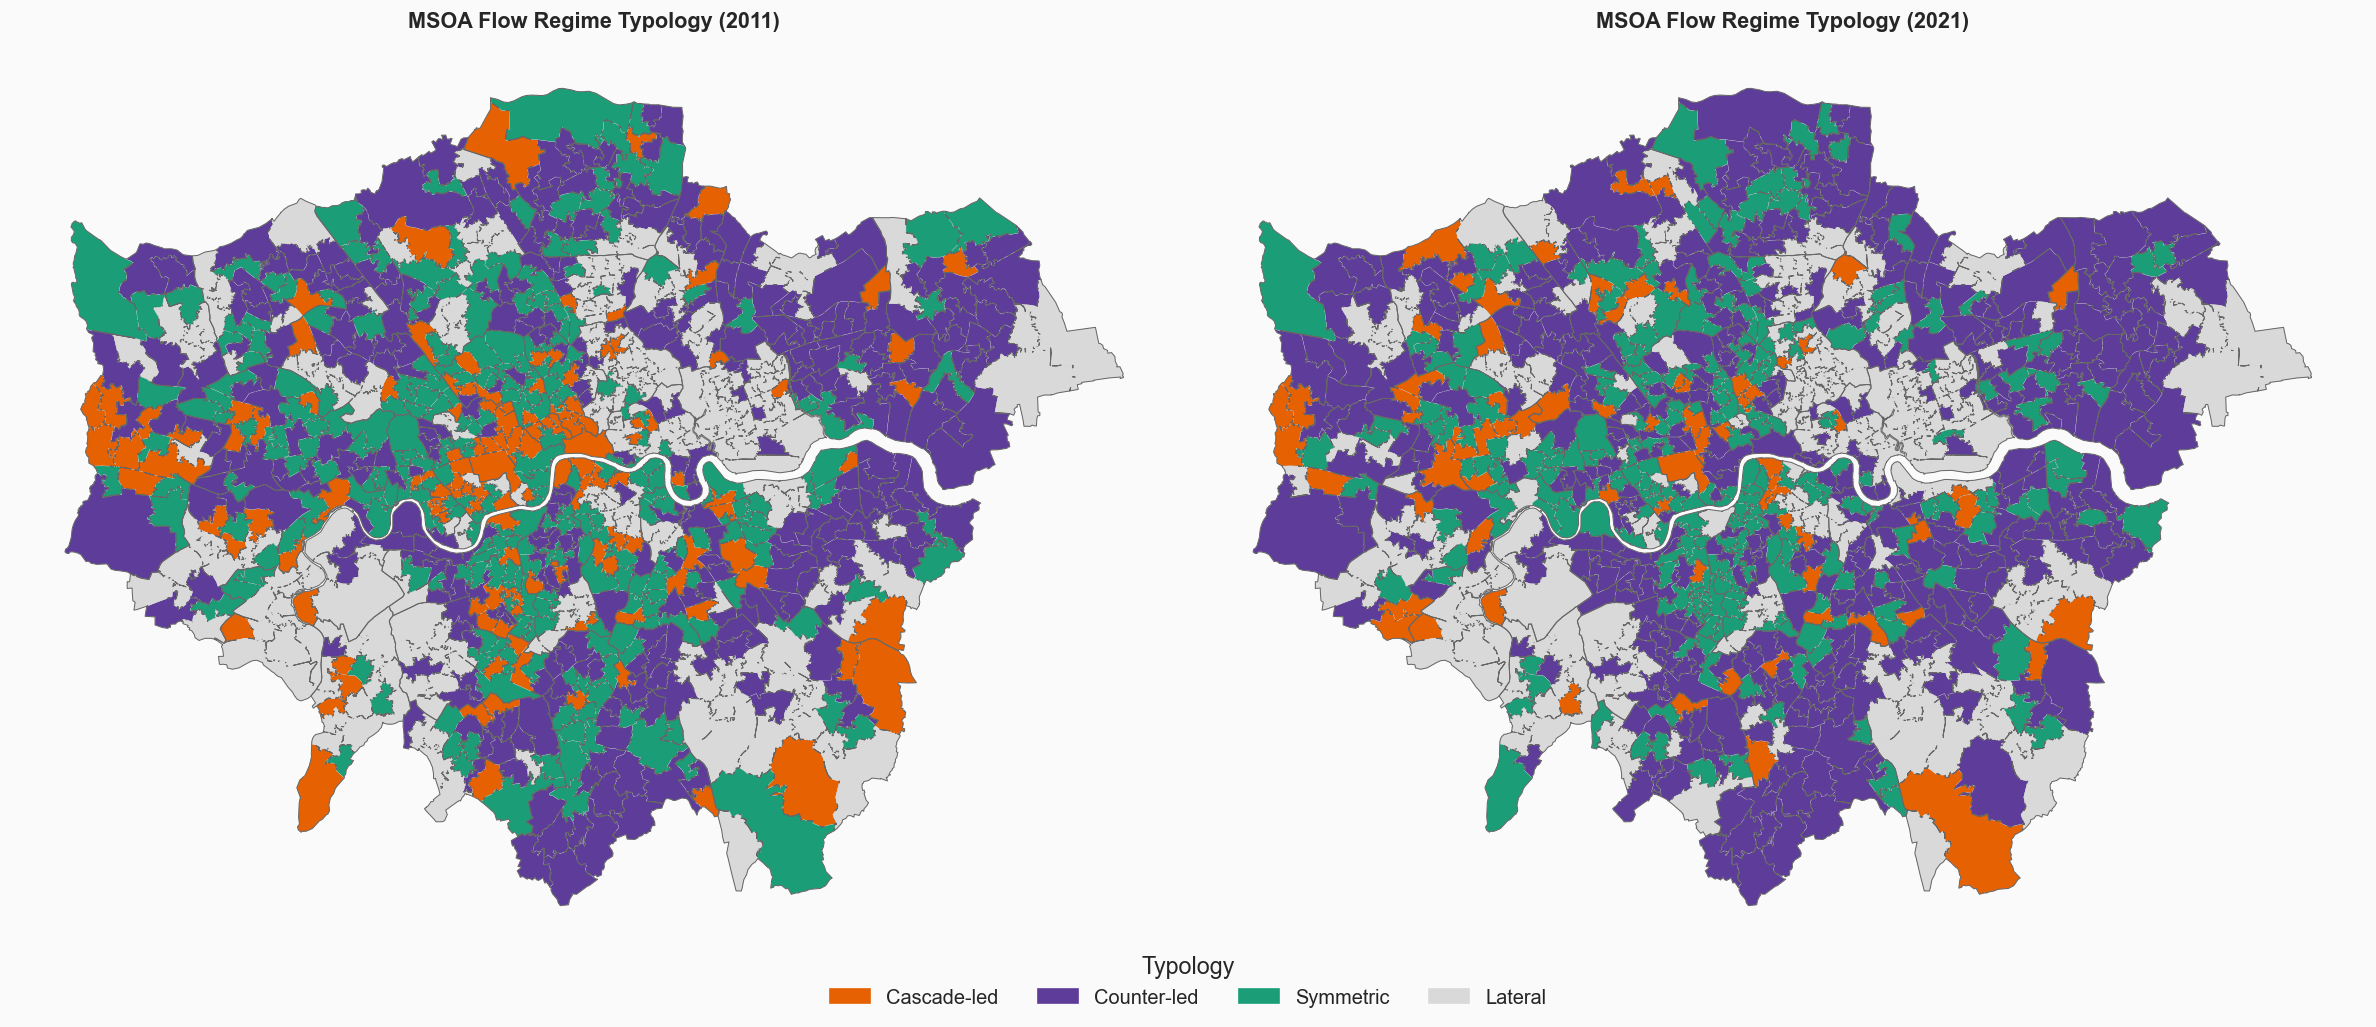

In [63]:
gdf = load_london_msoa(GEO_PATH, df)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    plot_london_categorical(
        gdf, column=f'Typology_{yr}',
        title=f'MSOA Flow Regime Typology (20{yr})',
        color_dict=TYPOLOGY_COLORS,
        ax=ax
    )
    ax.get_legend().remove()

legend_patches = [
    mpatches.Patch(color=color, label=label) 
    for label, color in TYPOLOGY_COLORS.items()
]

fig.legend(
    handles=legend_patches,
    title='Typology',
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=4,                      
    fontsize=12,
    title_fontsize=14,
    frameon=False             
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_14_typology_map.png', bbox_inches='tight', dpi=150)
plt.show()

### Fig 14 Interpretation

**`Cascade-led` MSOAs lose ground to `counter-led` ones from 2011 to 2021.**

**The inner-London cascade belt, especially inner South becomes more fragmented, while the outer-ring counter-cascade zone solidifies.**

- `Cascade-led` MSOAs are where the classic gentrification pressure mechanism is detectable.
    - In 2011, they cluster heavily in inner South and West London.
    - By 2021, orange patches thin out noticeably. This is consistent with the finding that London-wide mean cascade dominance dropped, and the system became slightly less cascade-dominated.
- `Counter-led` MSOAs are the largest category in both years, and it expands by 2021. This matches with Fig 11.
    - The spread of purple across outer East and North London in 2021 reinforces that counter-cascade flows gained ground everywhere.

- `Symmetric` MSOAs spatially scattered rather than concentrated. Balanced flow volumes aren't driven by a single geographical process.
    - `Cascade-led` clustered due to gentrification pressure tends to operate in identifiable zones (inner south and west in 2011).
    - `Counter-led` cluster due to another spatial logic with outer boroughs where wealthier residents leave and poorer ones arrive. 
    - `Symmetric` is more like a residual consition, wherever the two opposing pressures happen to cancel out. No geographical reason.

> Double check my design of cascade and counter-cascade. Do they fundamentally make sense? Would there be any problem in such design? If no, why counter-cascade dominated more, and we still have the tendency of more severe gentrification?
> Done. 2026-06-21.

=== Typology Transition Matrix (rows=2011, cols=2021) ===
Typology_21  Cascade-led  Counter-led  Lateral  Symmetric
Typology_11                                              
Cascade-led           25           48        7         50
Counter-led           14          240       15         71
Lateral                5           24      207         10
Symmetric             28          111       17        111

=== All Transitions (sorted by frequency) ===
Typology_Transition
Counter-led → Counter-led    240
Lateral → Lateral            207
Symmetric → Counter-led      111
Symmetric → Symmetric        111
Counter-led → Symmetric       71
Cascade-led → Symmetric       50
Cascade-led → Counter-led     48
Symmetric → Cascade-led       28
Cascade-led → Cascade-led     25
Lateral → Counter-led         24
Symmetric → Lateral           17
Counter-led → Lateral         15
Counter-led → Cascade-led     14
Lateral → Symmetric           10
Cascade-led → Lateral          7
Lateral → Cascade-led          5

/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)


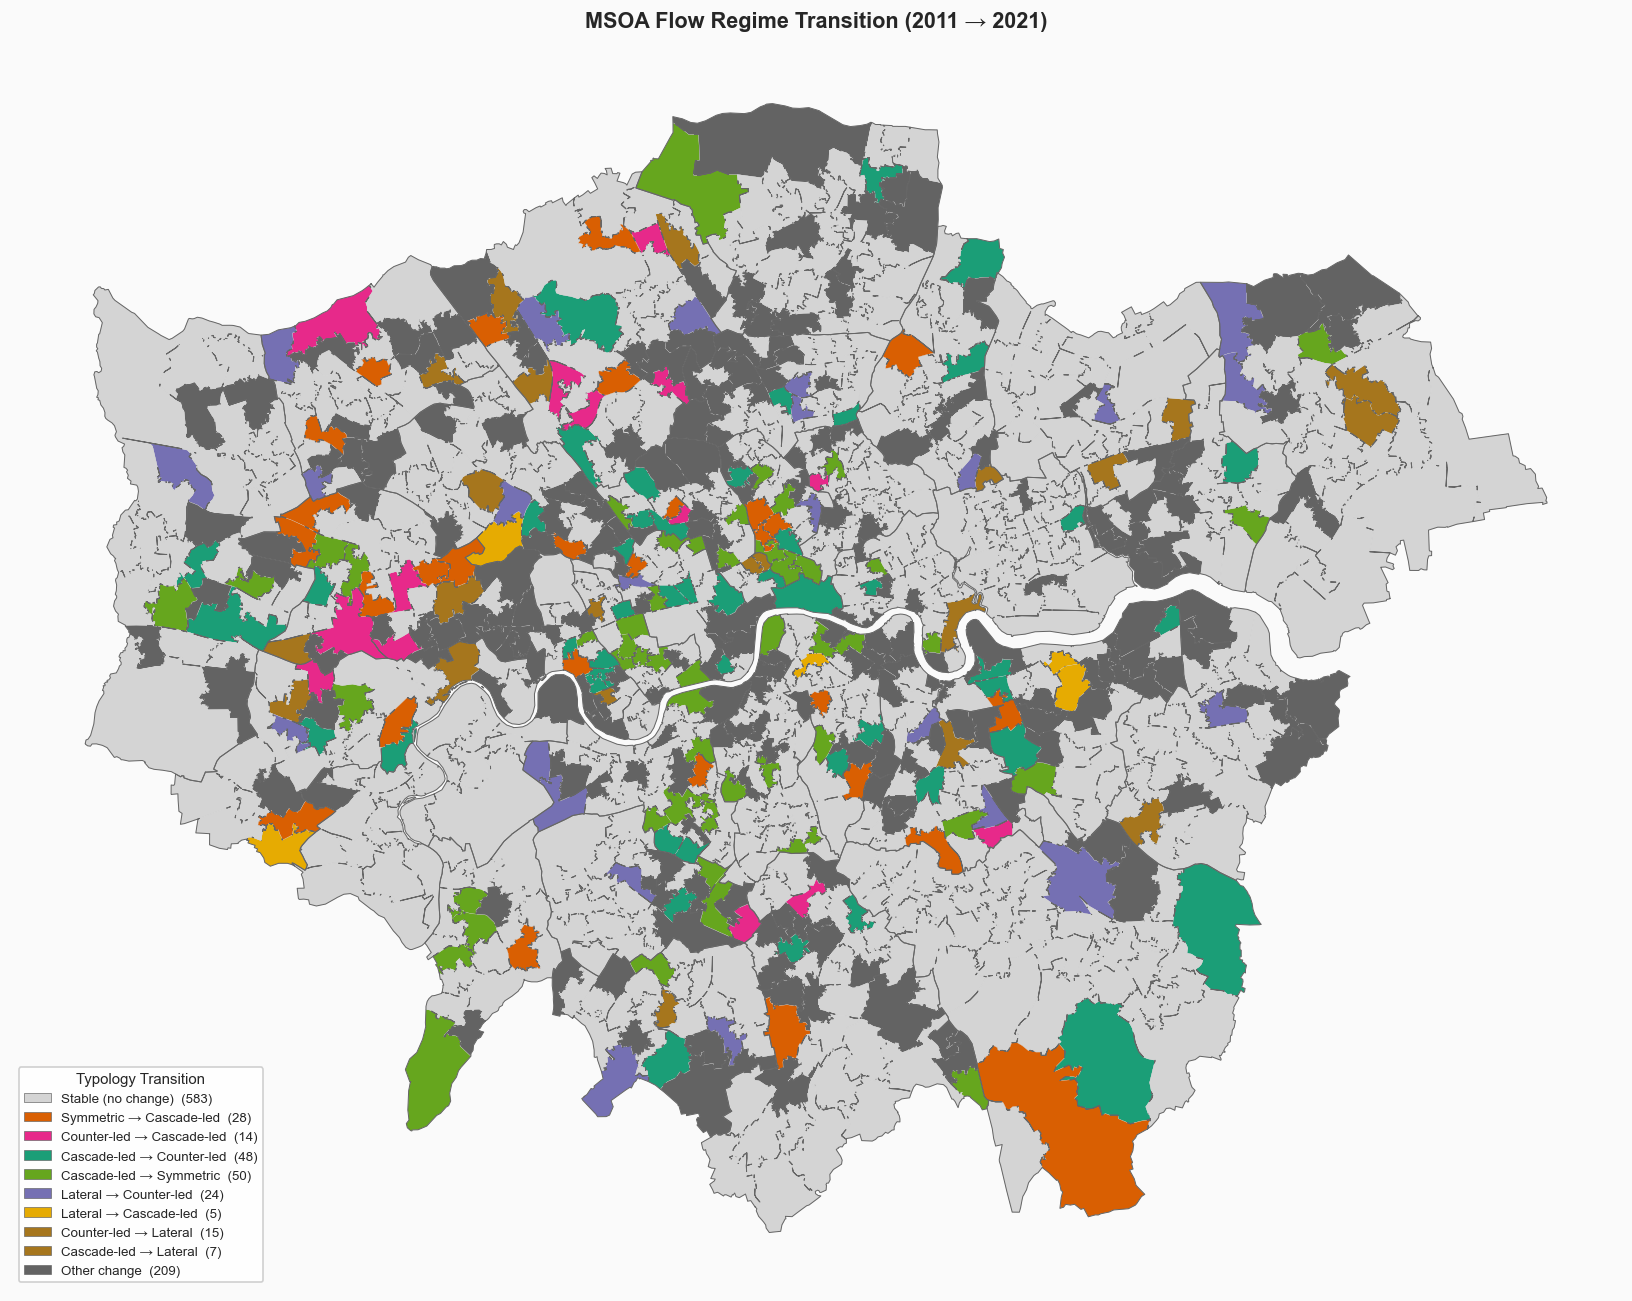


=== Mean IMD Percentile Change by Transition Group ===
                             n  mean_imd_chg  median_imd_chg
Transition_Group                                            
Lateral → Cascade-led        5        0.0340          0.0203
Cascade-led → Counter-led   48        0.0058          0.0066
Stable (no change)         583        0.0040          0.0020
Counter-led → Lateral       15        0.0037         -0.0285
Lateral → Counter-led       24        0.0032         -0.0056
Cascade-led → Symmetric     50        0.0017          0.0020
Other change               209       -0.0090         -0.0102
Symmetric → Cascade-led     28       -0.0149         -0.0239
Cascade-led → Lateral        7       -0.0275         -0.0743
Counter-led → Cascade-led   14       -0.0359         -0.0102


In [64]:
### Typology Transition Map (2011 → 2021)

# ── 1. Build transition labels ───────────────────────────────────
df['Typology_Transition'] = df['Typology_11'] + ' → ' + df['Typology_21']

# ── 2. Identify theoretically important transitions ──────────────
# Full cross-tab for diagnostics
ct = pd.crosstab(df['Typology_11'], df['Typology_21'])
print('=== Typology Transition Matrix (rows=2011, cols=2021) ===')
print(ct.to_string())
print()

# Count every transition
trans_counts = df['Typology_Transition'].value_counts()
print('=== All Transitions (sorted by frequency) ===')
print(trans_counts.to_string())
print()

# ── 3. Define display categories ─────────────────────────────────
# Theoretically important transitions get their own colour.
# "Stable" = same type in both periods → neutral grey.
# Rare transitions → grouped as "Other change".

STABLE_TYPES = [
    'Cascade-led → Cascade-led',
    'Counter-led → Counter-led',
    'Symmetric → Symmetric',
    'Lateral → Lateral',
]

# Key directional shifts (select the most common / analytically important)
HIGHLIGHT_TRANSITIONS = {
    # Gentrification pressure emerging or intensifying
    'Symmetric → Cascade-led':    '#d95f02',   # dark orange — new cascade pressure
    'Counter-led → Cascade-led':  '#e7298a',   # magenta    — reversal to cascade

    # Gentrification pressure dissipating
    'Cascade-led → Counter-led':  '#1b9e77',   # teal       — cascade reversed
    'Cascade-led → Symmetric':    '#66a61e',   # olive-green — cascade weakened

    # Lateral opening up (previously insulated, now engaged)
    'Lateral → Counter-led':      '#7570b3',   # slate-purple — lateral → counter
    'Lateral → Cascade-led':      '#e6ab02',   # gold         — lateral → cascade

    # Closing down (cross-decile exchange declining)
    'Counter-led → Lateral':      '#a6761d',   # brown — counter → lateral
    'Cascade-led → Lateral':      '#a6761d',   # brown — same colour (both → insulated)
}

def classify_transition(t):
    if t in STABLE_TYPES:
        return 'Stable (no change)'
    elif t in HIGHLIGHT_TRANSITIONS:
        return t
    else:
        return 'Other change'

df['Transition_Group'] = df['Typology_Transition'].apply(classify_transition)

# ── 4. Colour dictionary for the map ─────────────────────────────
TRANSITION_COLORS = {
    'Stable (no change)': '#d4d4d4',       # light grey
    **HIGHLIGHT_TRANSITIONS,
    'Other change':       '#636363',       # dark grey
}

# Prune to transitions that actually appear in the data
present = set(df['Transition_Group'].unique())
TRANSITION_COLORS = {k: v for k, v in TRANSITION_COLORS.items() if k in present}

# Print group sizes
print('=== Transition Groups ===')
print(df['Transition_Group'].value_counts().to_string())
print()

# ── 5. Merge onto geodataframe and plot ──────────────────────────
# Refresh gdf with new columns
gdf = load_london_msoa(GEO_PATH, df)

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

plot_london_categorical(
    gdf,
    column='Transition_Group',
    title='MSOA Flow Regime Transition (2011 → 2021)',
    color_dict=TRANSITION_COLORS,
    ax=ax
)

# ── 6. Custom legend (ordered: stable first, then highlights, then other) ──
legend_order = ['Stable (no change)']
legend_order += [t for t in HIGHLIGHT_TRANSITIONS if t in present]
legend_order += ['Other change'] if 'Other change' in present else []

handles = [
    mpatches.Patch(facecolor=TRANSITION_COLORS[t], edgecolor='#666666',
                   linewidth=0.4, label=f'{t}  ({(df["Transition_Group"]==t).sum()})')
    for t in legend_order
]

ax.legend(
    handles=handles,
    title='Typology Transition',
    loc='lower left',
    bbox_to_anchor=(0.0, 0.0),
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    framealpha=0.92,
    edgecolor='#cccccc',
    ncol=1,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_14b_typology_transition_map.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ── 7. Companion diagnostic: mean IMD change by transition group ─
print('\n=== Mean IMD Percentile Change by Transition Group ===')
diag = (df.groupby('Transition_Group')
          .agg(n=('msoa11cd', 'count'),
               mean_imd_chg=('IMD_Pctile_Change', 'mean'),
               median_imd_chg=('IMD_Pctile_Change', 'median'))
          .sort_values('mean_imd_chg', ascending=False)
          .round(4))
print(diag.to_string())

### Fig 14b Interpretation

- 583 of 983 (58%) MSOAs had no change across the decade.
    - **Our typology is capturing something stucturally persistent about how neighbourhoods sit within the migration system, not just picking up census-period noise.**
    - This strengthens the typology's credibility as a classification tool.
- Cascade-led changes have spatial pattern.
    - When cascade-led MSOAs changes between dominance metrics, they split roughly evenly between becoming counter-led and becoming symmetric.
    - These changes concentrate in inner West and inner South London, which is the classic gentrification belt.
    - **Callback with EDA_2, cascade pressure did not just weaken uniformly, it fragmented specifically in areas that were the most actively restructuring in 2011.**
        - if gentrification-via-displacement was sustained or exhausted across the decade?
- "Other change" category has 209 MSOAs (e.g. symmetric to counter-led, symmetric to lateral, counter-led to symmetric, etc.)
    - **This category dominates the outer North and East London, meaning these outer areas have unstable flow regimes that shift between balanced and counter-cascade states without following the cascade-centric narrative.**
    - This is a limitation need to flag. **The typology is most analytically powerful for the inner-London areas, where cascade dynamics are strongest, and outer ring areas, where cross-decile flows are lower-volume and more volatile.**


---

## 15c. Reflect on Counter-led dominance

> If cascade and counter-cascade are "opposite sides of the same coin," why would one side systematically dominate?

(Codes for analysis below)

The structural explanation is the **"escalator effect" by Fielding (1992)**.
- **People who move within the city tend, on average, to move toward less deprived areas. **
- This is a well-documented feature of London's internal migration system.
    - Households trade up when they can (aspirational mobility)
    - Young renters in deprived inner areas buy in less deprived suburbs (lifecycle progression).
    - Social housing allocation patterns can move people across the hierarchy.

Cascade direction captures the gentrification-related downward displacement. Counter-cascade direction captures the upward tendency. 
- The background rate of upward mobility exceeds the rate of downward displacement on average across the city.
- **Gentrification is a localised perturbation that tilts specific neighbourhoods against the prevailing current.**

---

> Why the gap of counter-dominance widen between 2011 and 2021?

**The counter/cascade ratio (PANEL a) grew from 1.06 to 1.13. The upward bias intensified.**
- The 2021 census captured a COVID-era migration snapshot where "flight to the suburbs" amplified upward moves
    - Meanwhile, cascade-direction moves were surpressed becaused the pandemic reduced short-distance gentrification-related relocations.
- This could also partly reflect **a decade of inner-London gentrification had by 2021 already "completed" in many areas.**
    - **Active cascade zones in 2011 were into settled, post-transition neighbourhoods.**

We showed that **Gentrification-related displacement (cascade) operates as a minority counter-current against London's dominant upward-mobility flow**.
- Cascade signal is real. It concentrates in a specific subset of MSOAs while the majority of London runs on the reverse dynamic.
- **Rather than "cascading displacement is the dominant force reshaping London", the findings align with Marcuse's (1985) framework of displacement as a localised, relational process embedded within a broader urban system.**


---

> What's the relationship between the counter-led and the negative net_counter (divergent in sign concordance)? They seem both net exporters?

`Counter-led` and `Counter-positive`(divergent) are not the same. Of 423 counter-led MSOAs, only **14 (13.3%)** are counter positive divergent. 370 (87.5%) are concordant.
- `Counter-led` is a volume balance classification. It means counter-cascade churn (OW+IP) exceeds the cascade churn (IW+OP) as a share of total cross-decile activity. 
    - This shows which direction carries more traffic, but nothing about the net balance within each direction separately.
- Counter-positive divergent is a directional cosistency classification as a logical contradictory, where `Net_Cascade` < 0 and `Net_Counter` > 0.
    - More people leave for poorer areas than arrive from wealthier ones, yet simultaneously more people leave for wealthier areas than arrive from poorer ones.
    - Both outflow directions exceed their corresponding inflow directions. This is why it's a net exporter in both directions of the hierarchy.
- Key distinction in **PANEL d** below. 


In [94]:
# =====================================================================
# FORMULA REFERENCE
# =====================================================================
print('=' * 72)
print('FORMULA REFERENCE')
print('=' * 72)
print()
print('  CASCADE COMPONENTS (the gentrification-direction flows):')
print('    IW = Inflow_Wealthier   — people arriving FROM wealthier areas')
print('    OP = Outflow_Poorer     — people leaving TO poorer areas')
print('    Net_Cascade = IW − OP')
print('      Positive → more arrive from wealthier than leave to poorer')
print('      Negative → more leave to poorer than arrive from wealthier')
print()
print('  COUNTER-CASCADE COMPONENTS (the reverse-direction flows):')
print('    OW = Outflow_Wealthier  — people leaving TO wealthier areas')
print('    IP = Inflow_Poorer      — people arriving FROM poorer areas')
print('    Net_Counter = OW − IP')
print('      Positive → more leave to wealthier than arrive from poorer')
print('      Negative → more arrive from poorer than leave to wealthier')
print()
print('  KEY INSIGHT:')
print('    Net_Cascade < 0 means the CASCADE OUTFLOW (OP) dominates')
print('    Net_Counter < 0 means the COUNTER INFLOW (IP) dominates')
print('    Both negative (concordant) → area absorbs from poorer origins')
print('                                  while exporting in cascade direction')
print()

FORMULA REFERENCE

  CASCADE COMPONENTS (the gentrification-direction flows):
    IW = Inflow_Wealthier   — people arriving FROM wealthier areas
    OP = Outflow_Poorer     — people leaving TO poorer areas
    Net_Cascade = IW − OP
      Positive → more arrive from wealthier than leave to poorer
      Negative → more leave to poorer than arrive from wealthier

  COUNTER-CASCADE COMPONENTS (the reverse-direction flows):
    OW = Outflow_Wealthier  — people leaving TO wealthier areas
    IP = Inflow_Poorer      — people arriving FROM poorer areas
    Net_Counter = OW − IP
      Positive → more leave to wealthier than arrive from poorer
      Negative → more arrive from poorer than leave to wealthier

  KEY INSIGHT:
    Net_Cascade < 0 means the CASCADE OUTFLOW (OP) dominates
    Net_Counter < 0 means the COUNTER INFLOW (IP) dominates
    Both negative (concordant) → area absorbs from poorer origins
                                  while exporting in cascade direction



In [89]:
# ── Cascade vs Counter-Cascade: Volume Breakdown & Structural Asymmetry ──
# Three panels:
#   (a) London-wide flow volume comparison (2011 vs 2021)
#   (b) Decile-level directional composition showing the upward-mobility bias
#   (c) Cross-tabulation: Typology × Sign Concordance


# ── Reconstruct sign concordance detail ─────────────
for yr in ['11', '21']:
    col = f'Sign_Concordance_Detail_{yr}'
    if col not in df.columns:
        df[col] = df[f'Sign_Concordance_{yr}']
        nc  = df[f'Net_Cascade_{yr}']
        nco = df[f'Net_Counter_{yr}']
        div = df[f'Sign_Concordance_{yr}'] == 'divergent'
        df.loc[div & (nc > 0) & (nco < 0), col] = 'cascade-positive'
        df.loc[div & (nc < 0) & (nco > 0), col] = 'counter-positive'


# =====================================================================
# PANEL (a): London-wide flow volume comparison
# =====================================================================
print('=' * 72)
print('PANEL (a): London-Wide Flow Volume Comparison')
print('=' * 72)

rows = []
for yr in ['11', '21']:
    iw  = df[f'Inflow_Wealthier_{yr}'].sum()
    op  = df[f'Outflow_Poorer_{yr}'].sum()
    ow  = df[f'Outflow_Wealthier_{yr}'].sum()
    ip  = df[f'Inflow_Poorer_{yr}'].sum()
    tm  = df[f'Total_Migration_{yr}'].sum()
    
    unique_cascade = iw           
    unique_counter = ow           
    within_decile  = tm / 2 - unique_cascade - unique_counter

    excess_moves = unique_counter - unique_cascade
    excess_pct = (excess_moves / unique_cascade) * 100 

    rows.append({
        'Census': f'20{yr}',
        'Unique cascade (downward) moves': int(unique_cascade),
        'Unique counter-cascade (upward) moves': int(unique_counter),
        'Excess upward moves': int(excess_moves),
        'Excess upward (%)': excess_pct, 
        'Counter / Cascade ratio': unique_counter / unique_cascade,
        'Total cross-MSOA moves (approx)': int(tm / 2),
    })

vol_df = pd.DataFrame(rows).set_index('Census').T
print(vol_df.to_string(float_format="%.2f")) 
print()


pct_2011 = rows[0]['Excess upward (%)']
pct_2021 = rows[1]['Excess upward (%)']

pct_diff = pct_2021 - pct_2011

print('Interpretation:')
print('  Cascade  = people moving FROM wealthier TO poorer areas (downward)')
print('  Counter  = people moving FROM poorer TO wealthier areas (upward)')
print(f'  The upward bias grew from {rows[0]["Counter / Cascade ratio"]:.3f} '
      f'to {rows[1]["Counter / Cascade ratio"]:.3f} between censuses.')

print(f'  In 2011, there was an {pct_2011:.0f}% excess of upward movers.')
print(f'  In 2021, there was a {pct_2021:.0f}% excess of upward movers.')
print(f'  That represents an increase of {pct_diff:.0f}% points over the decade.')
print()

PANEL (a): London-Wide Flow Volume Comparison
Census                                     2011      2021
Unique cascade (downward) moves       309588.00 272493.00
Unique counter-cascade (upward) moves 327360.00 307840.00
Excess upward moves                    17772.00  35347.00
Excess upward (%)                          5.74     12.97
Counter / Cascade ratio                    1.06      1.13
Total cross-MSOA moves (approx)       768423.00 695667.00

Interpretation:
  Cascade  = people moving FROM wealthier TO poorer areas (downward)
  Counter  = people moving FROM poorer TO wealthier areas (upward)
  The upward bias grew from 1.057 to 1.130 between censuses.
  In 2011, there was an 6% excess of upward movers.
  In 2021, there was a 13% excess of upward movers.
  That represents an increase of 7% points over the decade.



In [87]:
# =====================================================================
# PANEL (b): Decile-level directional composition (2011 & 2021)
# =====================================================================

# Define the years and their corresponding column suffixes
years = {'2011': '_11', '2021': '_21'}

for year, suffix in years.items():
    print('=' * 72)
    print(f'PANEL (b): Directional Composition of Flows by Wealth Decile ({year})')
    print('=' * 72)

    # Dynamically aggregate based on the year's suffix
    grp = df.groupby('Wealth_Decile').agg({
        f'Total_Inflow{suffix}': 'sum',
        f'Total_Outflow{suffix}': 'sum',
        f'Inflow_Wealthier{suffix}': 'sum',
        f'Outflow_Wealthier{suffix}': 'sum',
        f'Inflow_Poorer{suffix}': 'sum',
        f'Outflow_Poorer{suffix}': 'sum',
    }).rename(columns=lambda c: c.replace(suffix, '')) # Strip the suffix for standard calculations

    # Percentage shares
    comp = pd.DataFrame({
        '% Inflow from Wealthier (IW)':
            (grp['Inflow_Wealthier'] / grp['Total_Inflow'] * 100).round(1),
        '% Outflow to Wealthier (OW)':
            (grp['Outflow_Wealthier'] / grp['Total_Outflow'] * 100).round(1),
        '% Outflow to Poorer (OP)':
            (grp['Outflow_Poorer'] / grp['Total_Outflow'] * 100).round(1),
        '% Inflow from Poorer (IP)':
            (grp['Inflow_Poorer'] / grp['Total_Inflow'] * 100).round(1),
    })
    
    comp['Gap: OW% − IW%'] = (comp['% Outflow to Wealthier (OW)']
                                - comp['% Inflow from Wealthier (IW)']).round(1)
    
    print(comp.to_string())
    print() # Adds a blank line between the 2011 and 2021 tables

PANEL (b): Directional Composition of Flows by Wealth Decile (2011)
               % Inflow from Wealthier (IW)  % Outflow to Wealthier (OW)  % Outflow to Poorer (OP)  % Inflow from Poorer (IP)  Gap: OW% − IW%
Wealth_Decile                                                                                                                                
1                                      70.7                         71.9                       0.0                        0.0             1.2
2                                      60.1                         62.4                      18.9                       20.2             2.3
3                                      52.9                         55.7                      29.3                       31.8             2.8
4                                      47.5                         47.7                      38.3                       38.7             0.2
5                                      42.7                         44.7        

### Interpretation

**OW% > IW% at every decile** (gap column always non-negative).
- At every level of the hierarchy, outflows skew MORE toward wealthier destinations than inflows come from wealthier origins.
- Movers systematically move UP the deprivation ladder.
- This structural upward-mobility bias is why counter-cascade dominates London-wide.

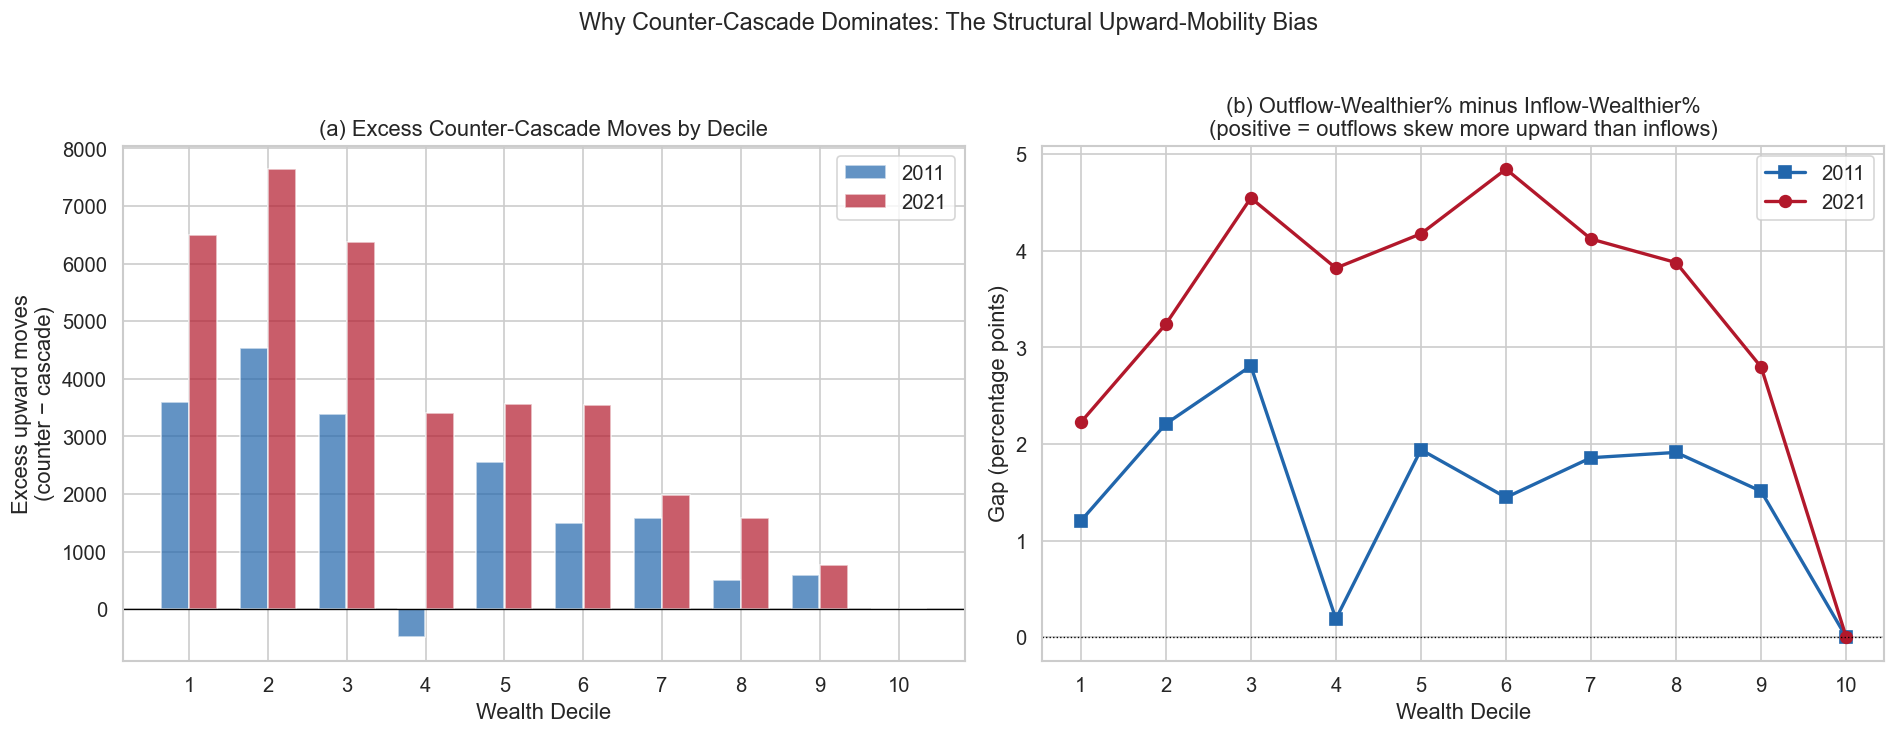

In [95]:
# =====================================================================
# PANEL (b) Visualisation: Volume breakdown + Gap chart
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# --- Left panel: excess upward moves by decile ---
ax = axes[0]
deciles = range(1, 11)
for yr, color, label in [('11', '#2166ac', '2011'), ('21', '#b2182b', '2021')]:
    cascade_vol = df.groupby('Wealth_Decile')[f'Inflow_Wealthier_{yr}'].sum()
    counter_vol = df.groupby('Wealth_Decile')[f'Outflow_Wealthier_{yr}'].sum()
    excess = counter_vol - cascade_vol
    ax.bar([d + (-0.18 if yr == '11' else 0.18) for d in deciles],
           excess, width=0.35, color=color, alpha=0.7, label=label)
 
ax.set_xlabel('Wealth Decile')
ax.set_ylabel('Excess upward moves\n(counter − cascade)')
ax.set_title('(a) Excess Counter-Cascade Moves by Decile')
ax.set_xticks(range(1, 11))
ax.axhline(0, color='black', lw=0.8)
ax.legend()
 
# --- Right panel: OW% − IW% gap ---
ax = axes[1]
for yr, color, marker, label in [('11', '#2166ac', 's', '2011'),
                                   ('21', '#b2182b', 'o', '2021')]:
    grp_yr = df.groupby('Wealth_Decile').agg({
        f'Total_Inflow_{yr}': 'sum',  f'Inflow_Wealthier_{yr}': 'sum',
        f'Total_Outflow_{yr}': 'sum', f'Outflow_Wealthier_{yr}': 'sum',
    })
    pct_iw = grp_yr[f'Inflow_Wealthier_{yr}'] / grp_yr[f'Total_Inflow_{yr}'] * 100
    pct_ow = grp_yr[f'Outflow_Wealthier_{yr}'] / grp_yr[f'Total_Outflow_{yr}'] * 100
    gap = pct_ow - pct_iw
    ax.plot(gap.index, gap.values, f'-{marker}', color=color, label=label,
            markersize=7, lw=2)
 
ax.set_xlabel('Wealth Decile')
ax.set_ylabel('Gap (percentage points)')
ax.set_title('(b) Outflow-Wealthier% minus Inflow-Wealthier%\n'
             '(positive = outflows skew more upward than inflows)')
ax.set_xticks(range(1, 11))
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.legend()
 
plt.suptitle('Why Counter-Cascade Dominates:'
             ' The Structural Upward-Mobility Bias',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_14c_cascade_counter_volume_breakdown.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [79]:
# =====================================================================
# PANEL (c): Cross-tabulation — Typology × Sign Concordance
# =====================================================================
print('=' * 72)
print('PANEL (c): Typology × Sign Concordance Cross-Tabulation (2021)')
print('=' * 72)

ct = pd.crosstab(df['Typology_21'], df['Sign_Concordance_Detail_21'],
                 margins=True)
# Reorder
order_typ = ['Cascade-led', 'Counter-led', 'Symmetric', 'Lateral', 'All']
order_sc  = ['concordant', 'cascade-positive', 'counter-positive', 'zero', 'All']
ct = ct.reindex(index=[o for o in order_typ if o in ct.index],
                columns=[o for o in order_sc if o in ct.columns])

print('\nCounts:')
print(ct.to_string())

# Percentage within each typology
ct_pct = pd.crosstab(df['Typology_21'], df['Sign_Concordance_Detail_21'],
                      normalize='index') * 100
ct_pct = ct_pct.reindex(index=[o for o in order_typ if o in ct_pct.index],
                         columns=[o for o in order_sc if o in ct_pct.columns])
print('\nRow percentages (% within each typology):')
print(ct_pct.round(1).to_string())
print()

PANEL (c): Typology × Sign Concordance Cross-Tabulation (2021)

Counts:
Sign_Concordance_Detail_21  concordant  cascade-positive  counter-positive  zero  All
Typology_21                                                                          
Cascade-led                         67                 3                 2     0   72
Counter-led                        370                39                14     0  423
Symmetric                          226                 6                 9     1  242
Lateral                            202                 7                17    20  246
All                                865                55                42    21  983

Row percentages (% within each typology):
Sign_Concordance_Detail_21  concordant  cascade-positive  counter-positive  zero
Typology_21                                                                     
Cascade-led                       93.1               4.2               2.8   0.0
Counter-led                       87.5  

In [97]:
# =====================================================================
# PANEL (d): Distinction between `Counter-led` and `Counter-positive`divergent
# =====================================================================
print('=' * 72)
print('PANEL (d): Flow Anatomy by Typology × Concordance (2021)')
print('=' * 72)
print()
print('  Columns: IW, OP (cascade);  OW, IP (counter-cascade)')
print('           NC = Net_Cascade = IW−OP;  NCo = Net_Counter = OW−IP')
print('           Dom = Cascade_Dominance;  N = count')
print()
 
df['_Typ_SC'] = df['Typology_21'] + ' | ' + df['Sign_Concordance_Detail_21']
 
anatomy_cols = {
    'Inflow_Wealthier_21':  'IW',
    'Outflow_Poorer_21':    'OP',
    'Outflow_Wealthier_21': 'OW',
    'Inflow_Poorer_21':     'IP',
    'Net_Cascade_21':       'NC',
    'Net_Counter_21':       'NCo',
    'Cascade_Dominance_21': 'Dom',
}
 
anat = df.groupby('_Typ_SC')[list(anatomy_cols.keys())].agg(['mean', 'count'])
 
summary_rows = []
for label in anat.index:
    n = int(anat.loc[label, ('Inflow_Wealthier_21', 'count')])
    row = {'Category': label, 'N': n}
    for col, short in anatomy_cols.items():
        row[short] = round(anat.loc[label, (col, 'mean')], 1)
    summary_rows.append(row)
 
summary = pd.DataFrame(summary_rows).set_index('Category')
summary = summary[summary['N'] >= 3].sort_values('N', ascending=False)
print(summary.to_string())
print()
 
df.drop(columns='_Typ_SC', inplace=True)

PANEL (d): Flow Anatomy by Typology × Concordance (2021)

  Columns: IW, OP (cascade);  OW, IP (counter-cascade)
           NC = Net_Cascade = IW−OP;  NCo = Net_Counter = OW−IP
           Dom = Cascade_Dominance;  N = count

                                  N     IW     OP     OW     IP     NC    NCo  Dom
Category                                                                          
Counter-led | concordant        370  251.7  278.9  312.6  350.8  -27.2  -38.1  0.4
Symmetric | concordant          226  337.1  351.5  351.8  350.6  -14.4    1.2  0.5
Lateral | concordant            202  263.4  189.2  307.7  228.4   74.2   79.3  0.4
Cascade-led | concordant         67  327.4  361.4  278.0  297.9  -34.0  -19.9  0.5
Counter-led | cascade-positive   39  278.5  212.4  265.1  358.2   66.1  -93.1  0.4
Lateral | zero                   20    0.0    0.0    0.0    0.0    0.0    0.0  0.5
Lateral | counter-positive       17  239.8  291.9  371.8  259.8  -52.1  112.0  0.5
Counter-led | counter-positi

### Interpretation 2021 - Dominance vs. Sign concordance

**Concordant categories**
- Counter-led concordant:
    - Both NC and NCo are negative. ---> Downward-connected Hub
- Symmetric concordant:
    - Both NC and NCo are roughly zero.
    - Cascade and counter-cascade volumes are roughly balanced, and neither net direction is strongly signed.
    - These are areas with active population circulation in both directions but no dominant directional tendency.
- Lateral concordant:
    - Both NC and NCo are positive. --- Upward-connected Hub.
    - **CDS is low.**
        - Most migration in these areas stays within the same decile level.
- Cascade-led concordant:
    - Both NC and NCo are negative. ---> Downward-connected Hub

**Divergent categories - Cascade-positive (Net receiver of all movers)**
- Counter-led:
    - 
- Cascade-led:
    - Only N=3 MSOAs 
    - 
- Symmetric:
- Lateral:

**Divergent categories - Counter-positive (Net exporter of all movers)**
- Counter-led:
    - 
- Cascade-led:
    - Only N=2 MSOAs
- Symmetric:
- Lateral:

**(Need a map to show each classification.**
**Need to connect the check with cross-decile share, for alignment of classidication.**
**Need 2011 summary table and the comparison between 2011 and 2021.)**

- A counter-led *concordant* MSOA is a suburb absorption zone that received migrants from all directions, with slightly more coming via the counter-cascade channel.
- A *counter-positive divergent* MSOA is an area **haemorrhaging residents in both directions of the hierarchy,** like a pressure point in the urban system where people are being squeezed out regardless of whether they move up or down.
    - These are in inner-London (Newham, Hackney, Tower Hamlets areas)
    - **These are arguably the strongest displacement signal**

---
## 16. Typology Profiles

For each type: mean metrics, decile composition, borough composition.

In [65]:
# ── Mean metrics per typology ──────────────────────────────────
profile_cols = [
    'CFI_Churn_21', 'Counter_Churn_21', 'Net_Cascade_21', 'Net_Counter_21',
    'CFI_Rate_21', 'Counter_Rate_21',
    'Pct_Inflow_Wealthier_21', 'Pct_Outflow_Wealthier_21',
    'Cascade_Dominance_21', 'Cross_Decile_Share_21',
    'Total_Migration_21', 'IMD_Pctile_Change'
]

print('=== Mean Metric Values by Typology (2021) ===')
profile = df.groupby('Typology_21')[profile_cols].mean().round(2)
print(profile.T.to_string())

=== Mean Metric Values by Typology (2021) ===
Typology_21               Cascade-led  Counter-led  Lateral  Symmetric
CFI_Churn_21                   688.01       525.99   423.82     697.09
Counter_Churn_21               576.44       658.71   501.59     711.37
Net_Cascade_21                 -29.76       -19.60    58.56     -16.41
Net_Counter_21                 -19.00       -39.07    69.43       3.36
CFI_Rate_21                     40.69        37.05    16.42      53.36
Counter_Rate_21                 32.93        58.12    21.05      57.82
Pct_Inflow_Wealthier_21         45.52        35.12    30.47      41.85
Pct_Outflow_Wealthier_21        43.64        42.95    33.24      43.74
Cascade_Dominance_21             0.54         0.44     0.45       0.50
Cross_Decile_Share_21            0.88         0.87     0.65       0.87
Total_Migration_21            1451.82      1360.77  1304.11    1613.16
IMD_Pctile_Change               -0.01        -0.02     0.03       0.01


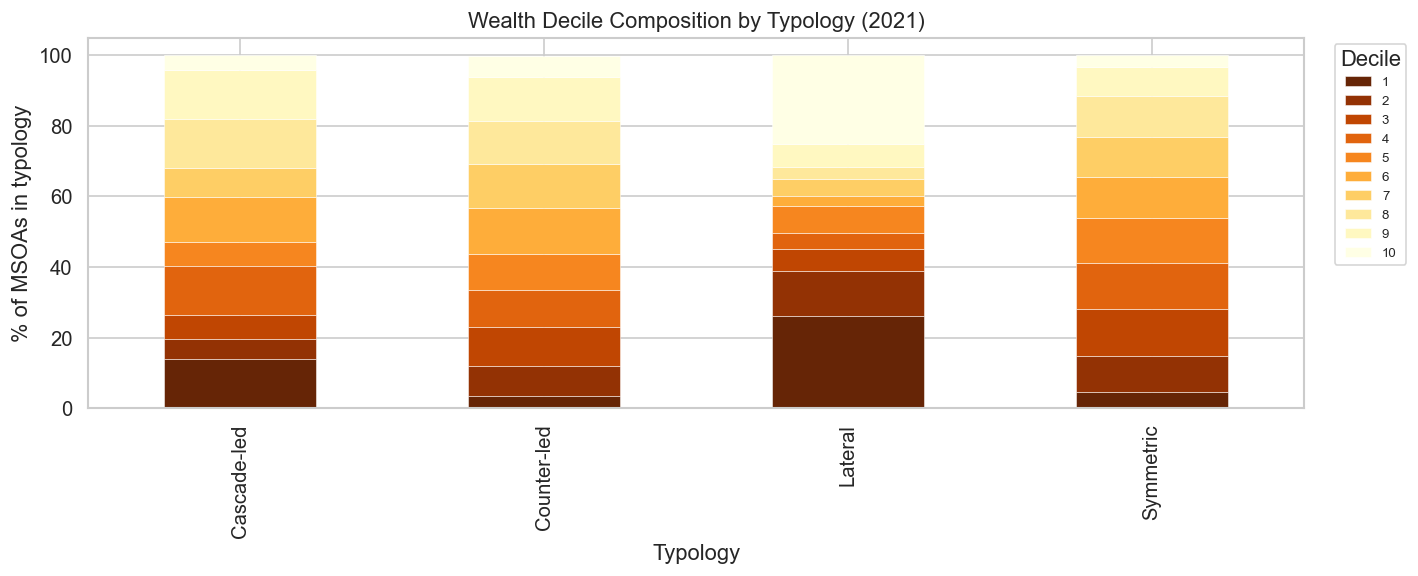

In [70]:
# ── Decile composition per typology ────────────────────────────
ct_decile = pd.crosstab(df['Typology_21'], df['Wealth_Decile'], normalize='index')
ct_decile = (ct_decile * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
ct_decile.plot(kind='bar', stacked=True, cmap='YlOrBr_r', ax=ax, edgecolor='white', lw=0.3)
ax.set_xlabel('Typology')
ax.set_ylabel('% of MSOAs in typology')
ax.set_title('Wealth Decile Composition by Typology (2021)')
ax.legend(title='Decile', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_15_typology_decile_composition.png', bbox_inches='tight')
plt.show()

### Fig 15 Interpretation

**Cascade-led**
Consistent with the *rent-gap theory*, where cascading displacement operates most intensely in the deprived-to-middle band, where there's both a deprivation "gap" to exploit and enough wealthier neighbours to generate inflow.
- Spread farily even across deciles
- Some concentration in the midlle (D3-D7)

**Counter-led**

-  Spread farily even across deciles

Lateral

Symmetric

In [72]:
# ── Top boroughs per typology (2011 & 2021) ───────────────────
print('=== Top 5 Boroughs per Typology (2011 vs 2021) ===')

typologies = ['Cascade-led', 'Counter-led', 'Symmetric', 'Lateral']
years = ['21', '11'] 

for typ in typologies:
    print(f'\n {typ.upper()}')
    
    for year in years:
        col_name = f'Typology_{year}'
        
        subset = df[df[col_name] == typ]
        top = subset['ladnm'].value_counts().head(5)
        
        print(f'  20{year} ({len(subset)} MSOAs):')
        for borough, count in top.items():
            print(f'    {borough}: {count}')

=== Top 5 Boroughs per Typology (2011 vs 2021) ===

 CASCADE-LED
  2021 (72 MSOAs):
    Ealing: 9
    Barnet: 7
    Southwark: 7
    Harrow: 4
    Hillingdon: 4
  2011 (130 MSOAs):
    Camden: 10
    Southwark: 9
    Westminster: 9
    Hillingdon: 8
    Kensington and Chelsea: 8

 COUNTER-LED
  2021 (423 MSOAs):
    Croydon: 34
    Enfield: 23
    Havering: 23
    Redbridge: 22
    Brent: 20
  2011 (340 MSOAs):
    Croydon: 26
    Redbridge: 25
    Enfield: 20
    Havering: 20
    Bexley: 18

 SYMMETRIC
  2021 (242 MSOAs):
    Lambeth: 20
    Ealing: 17
    Wandsworth: 16
    Camden: 13
    Barnet: 11
  2011 (267 MSOAs):
    Ealing: 18
    Wandsworth: 17
    Lewisham: 16
    Camden: 15
    Croydon: 15

 LATERAL
  2021 (246 MSOAs):
    Newham: 30
    Hackney: 22
    Tower Hamlets: 18
    Richmond upon Thames: 15
    Bromley: 14
  2011 (246 MSOAs):
    Newham: 31
    Hackney: 21
    Tower Hamlets: 16
    Bromley: 15
    Richmond upon Thames: 15


---
## Phase F — Does the Typology Predict Deprivation Change?

IMD_Pctile_Change is the external validation, constructed independently from the cascade metrics. Positive = moved up in national ranking = less deprived.

---
## 17. Correlation with IMD_Pctile_Change

In [ ]:
# ── Scatterplots: key metrics vs IMD_Pctile_Change ────────────
validation_metrics = [
    'Net_Cascade_21', 'Net_Counter_21',
    'CFI_Churn_21', 'Counter_Churn_21',
    'Cascade_Dominance_21', 'Cross_Decile_Share_21'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(validation_metrics):
    ax = axes.flatten()[i]
    ax.scatter(df[col], df['IMD_Pctile_Change'], s=8, alpha=0.3, edgecolor='none')
    
    # Spearman correlation
    rho, pval = stats.spearmanr(df[col], df['IMD_Pctile_Change'])
    ax.set_title(f'{col.replace("_21", "")}\nρ = {rho:.3f} (p = {pval:.1e})',
                 fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('IMD Pctile Change')
    
    # Regression line
    z = np.polyfit(df[col], df['IMD_Pctile_Change'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color='#b2182b', lw=1.5, ls='--')

fig.suptitle('Cascade & Counter-Cascade Metrics vs IMD Percentile Change',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_16_validation_scatters.png')
plt.show()

In [ ]:
# ── Partial correlations (controlling for Wealth_Decile) ──────
from scipy.stats import spearmanr

def partial_spearman(x, y, z):
    """Partial Spearman correlation of x and y, controlling for z."""
    # Rank-based: correlate residuals from regressing ranks on z
    from numpy.polynomial.polynomial import polyfit, polyval
    rx, ry, rz = stats.rankdata(x), stats.rankdata(y), stats.rankdata(z)
    # Residualize x and y on z
    cx = np.polyfit(rz, rx, 1)
    cy = np.polyfit(rz, ry, 1)
    resid_x = rx - np.polyval(cx, rz)
    resid_y = ry - np.polyval(cy, rz)
    return stats.spearmanr(resid_x, resid_y)

print('Validation: Spearman ρ with IMD_Pctile_Change')
print('=' * 70)
print(f'{"Metric":>28s} {"Raw ρ":>10s} {"Partial ρ":>10s} {"(ctrl W.D.)":>12s}')
print('─' * 70)

for col in validation_metrics:
    rho_raw, p_raw = stats.spearmanr(df[col], df['IMD_Pctile_Change'])
    rho_part, p_part = partial_spearman(df[col], df['IMD_Pctile_Change'], df['Wealth_Decile'])
    print(f'{col.replace("_21",""):>28s} {rho_raw:>+10.3f} {rho_part:>+10.3f} {"(p=" + f"{p_part:.1e}" + ")":>12s}')

---
## 18. Typology vs IMD Percentile Change

The ultimate validation: does the typology separate neighbourhoods with
different deprivation trajectories?

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

order = ['Cascade-led', 'Symmetric', 'Counter-led', 'Lateral']
colors = [TYPOLOGY_COLORS[t] for t in order]

bp = df.boxplot(column='IMD_Pctile_Change', by='Typology_21',
                positions=range(len(order)), ax=ax, patch_artist=True,
                return_type='dict', widths=0.6)

# Style the boxes
for i, (box, median) in enumerate(zip(bp['IMD_Pctile_Change']['boxes'],
                                       bp['IMD_Pctile_Change']['medians'])):
    box.set_facecolor(colors[i])
    box.set_alpha(0.6)
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xticklabels(order, fontsize=10)
ax.set_xlabel('Flow Regime Typology')
ax.set_ylabel('IMD Percentile Change (positive = less deprived)')
ax.set_title('')
fig.suptitle('IMD Percentile Change by Flow Regime Typology (2021)', fontsize=13)

# Kruskal-Wallis test
groups = [df.loc[df['Typology_21'] == t, 'IMD_Pctile_Change'].values for t in order]
kw_stat, kw_p = stats.kruskal(*groups)
ax.annotate(f'Kruskal-Wallis H = {kw_stat:.1f}, p = {kw_p:.2e}',
            xy=(0.98, 0.02), xycoords='axes fraction', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_17_typology_vs_imd_boxplot.png')
plt.show()

---
## 19. Export Typology Labels

In [ ]:
# Export typology labels for downstream use (File 4 + 5)
export_cols = ['msoa11cd', 'ladnm', 'Wealth_Decile',
               'Typology_11', 'Typology_21',
               'Cascade_Dominance_21', 'Cross_Decile_Share_21',
               'IMD_Pctile_Change', 'Sign_Concordance_21']

export_df = df[export_cols].copy()
export_path = DATA_DIR / 'msoa_typology_labels.csv'
export_df.to_csv(export_path, index=False)

print(f'Typology labels exported: {export_path}')
print(f'Shape: {export_df.shape}')
print(f'\nTypology (2021):')
print(export_df['Typology_21'].value_counts().to_string())

---
## 20. Summary

### Phase E findings
- The typology space (Cascade_Dominance × Cross_Decile_Share) produces
  four interpretable flow regime types.
- Threshold sensitivity: the classification depends on the dominance bandwidth
  (±0.02 from 0.50) and the CDS percentile cutoff (25th). These should be
  tested for robustness.

### Phase F findings
- IMD_Pctile_Change validation: [to be filled after running]
- Partial correlations controlling for Wealth_Decile reveal which metrics
  carry information beyond hierarchy position.
- Typology boxplot: if the Kruskal-Wallis test is significant, the typology
  adds explanatory value for deprivation trajectories.

### Output
`msoa_typology_labels.csv` — consumed by File 4 (spatial synthesis) and
File 5 (case studies).

---
*Next: `eda_4_spatial_synthesis.ipynb` (Phase G)*